In [1]:
import pickle, os, vegas, time
import numpy as np
import multiprocessing as mp
import torch, itertools
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot as plt
from scipy.optimize import brentq
from utils import get_filepath
from binary_classifier import BinaryClassifier
plt.rc('axes', prop_cycle=plt.cycler(color=plt.get_cmap('Set1').colors))

In [2]:
config = {
    "data": {
        "prior_args": {
            "uniform": None,
            "normal": (5, 4),
            "exponential": (.1,),
            "grid": (0.2,)
        },
        "parameter_range": (0, 10),
        "std_dev": 2,
        "n_parameters": 2, #dimensions in data will be equal to n_parameters, i.e. 1 parameter (mean) per dimension
        "n_train": 70_000,
        "n_test": 15_000,
        "n_validation": 15_000
    },
    "classifier": {
        "n_inputs": 2, # must be equal to n_parameters
        "n_hidden_layers": 3,
        "n_units": 64
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 128,
        "n_epochs": 5,
        "model_iterations": 1
    }
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)

In [3]:
def integrate_nd_vegas(func, bounds, nitn=10, neval=10_000):
    """Compute an nD integral using VEGAS Monte Carlo integration.

    Args:
        func: Callable accepting a 1D array-like of length n.
        bounds: Sequence of (low, high) for each dimension.
        nitn: Number of VEGAS iterations.
        neval: Number of evaluations per iteration.

    Returns:
        (mean, sdev) tuple from the VEGAS result.
    """
    def _wrapped(x):
        x = np.asarray(x)
        if x.ndim == 1:
            return func(x)
        return np.asarray([func(xi) for xi in x])
    integrator = vegas.Integrator(bounds)
    result = integrator(_wrapped, nitn=nitn, neval=neval)
    return result.mean, result.sdev

#integrate_nd_vegas(lambda x: np.exp(-0.5 * np.sum((x - 5) ** 2) / 4), [(0, 10)] * 3, nitn=20, neval=100_000)

#### Prior Distirbutions:

In [6]:
def normalize(function, parameter_range, n_dimensions, fct_args):
    integral, _ = integrate_nd_vegas(lambda x: function(x, *fct_args), [(parameter_range[0], parameter_range[1])] * n_dimensions, nitn=20, neval=100_000)
    def result_fct(z): return function(z, *fct_args) / integral
    result_fct.__name__ = function.__name__
    return result_fct

def uniform(x, parameter_range):
    x = np.asarray(x)
    n_dimensions = config["data"]["n_parameters"]
    result = np.full(x.shape[:-1], 1. / (parameter_range[1] - parameter_range[0]) ** n_dimensions)
    mask = np.any((x < parameter_range[0]) | (x > parameter_range[1]), axis=-1)
    result[mask] = 0.
    if result.ndim == 0:
        return float(result)
    return result
def uniform_pdf(x):
    return uniform(x, config["data"]["parameter_range"])
uniform_pdf.__name__ = "uniform"
def draw_uniform(shape):
    return generator.uniform(config["data"]["parameter_range"][0], config["data"]["parameter_range"][1], size=(*shape, config["data"]["n_parameters"]))
draw_uniform.__name__ = "uniform"

def normal(x: np.ndarray, mean=5, std=3):
    x = np.asarray(x)
    return np.exp(-0.5 * np.sum(((x - mean) / std) ** 2, axis=-1))
normal_pdf = normalize(normal, config["data"]["parameter_range"], config["data"]["n_parameters"], config["data"]["prior_args"]["normal"])
def draw_normal(shape):
    mean, std = config["data"]["prior_args"]["normal"]
    return generator.normal(mean, std, size=(*shape, config["data"]["n_parameters"]))
draw_normal.__name__ = "normal"

def exponential(x, lam=.3):
    x = np.asarray(x)
    mask = np.all(x >= 0, axis=-1)
    vals = np.exp(-lam * np.sum(x, axis=-1))
    return np.where(mask, vals, 0.0)
exponential_pdf = normalize(exponential, config["data"]["parameter_range"], config["data"]["n_parameters"], config["data"]["prior_args"]["exponential"])
def draw_exponential(shape):
    lam = config["data"]["prior_args"]["exponential"][0]
    return generator.exponential(1/lam, size=(*shape, config["data"]["n_parameters"]))
draw_exponential.__name__ = "exponential"

def grid_fct(x, step=0.2):
    x = np.asarray(x)
    mask = np.all(np.isclose(np.mod(x, step), 0, atol=1e-3), axis=-1)
    return mask.astype(float)
grid_pdf = normalize(grid_fct, config["data"]["parameter_range"], config["data"]["n_parameters"], config["data"]["prior_args"]["grid"])
def draw_grid(shape):
    step = config["data"]["prior_args"]["grid"][0]
    n_points_per_axis = int((config["data"]["parameter_range"][1] - config["data"]["parameter_range"][0]) / step) + 1
    grid_points = np.linspace(config["data"]["parameter_range"][0], config["data"]["parameter_range"][1], n_points_per_axis)
    all_combinations = np.array(list(itertools.product(grid_points, repeat=config["data"]["n_parameters"])))
    indices = generator.choice(all_combinations.shape[0], size=shape[0], replace=True)
    return all_combinations[indices]
draw_grid.__name__ = "grid"

priors = [uniform_pdf, normal_pdf, exponential_pdf]#, grid_pdf]
prior_samplers = [draw_uniform, draw_normal, draw_exponential]#, draw_grid]
param_min, param_max = config["data"]["parameter_range"]

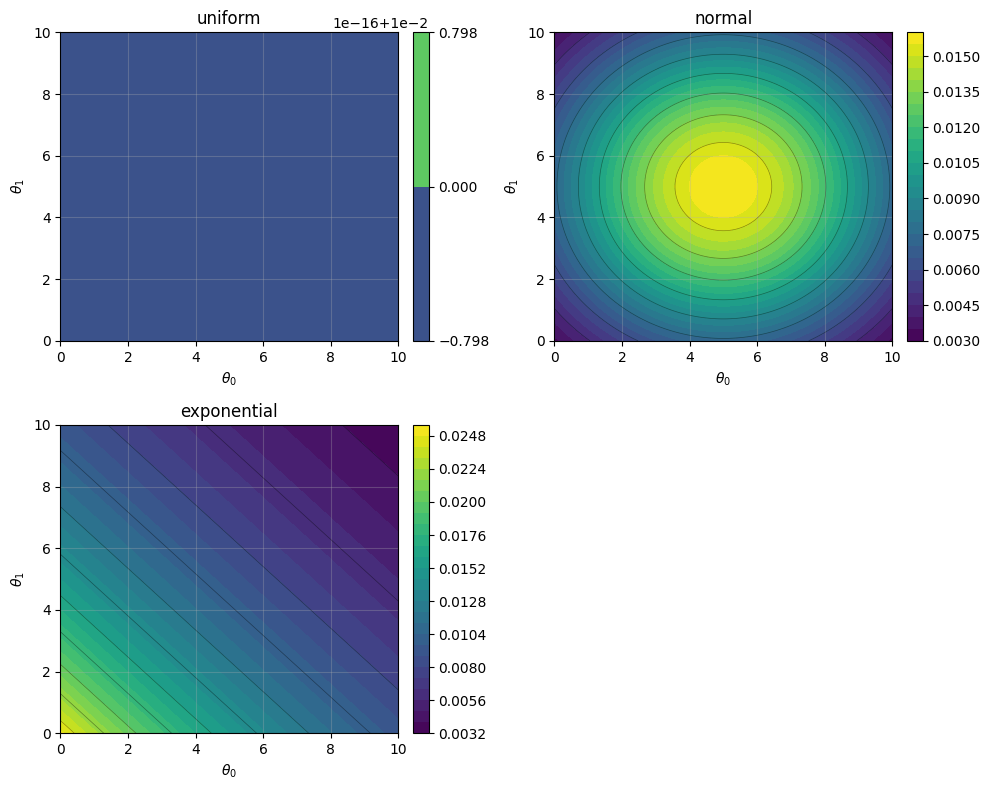

In [ ]:
# Contour plots of 2D priors
n_points = 200
theta = np.linspace(param_min, param_max, n_points)
X, Y = np.meshgrid(theta, theta, indexing="ij")
grid = np.stack([X, Y], axis=-1)

n_dimensions = len(priors)
ncols = min(2, n_dimensions)
nrows = (n_dimensions + ncols - 1) // ncols
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

for i, prior in enumerate(priors):
    Z = prior(grid)
    cf = axes[i].contourf(X, Y, Z, levels=30, cmap="viridis")
    axes[i].contour(X, Y, Z, levels=10, colors="k", linewidths=0.5, alpha=0.4)
    axes[i].set_title(prior.__name__)
    axes[i].set_xlabel(r"$\theta_0$")
    axes[i].set_ylabel(r"$\theta_1$")
    axes[i].grid(alpha=0.3)
    plt.colorbar(cf, ax=axes[i], fraction=0.046, pad=0.04)

for k in range(n_dimensions, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()

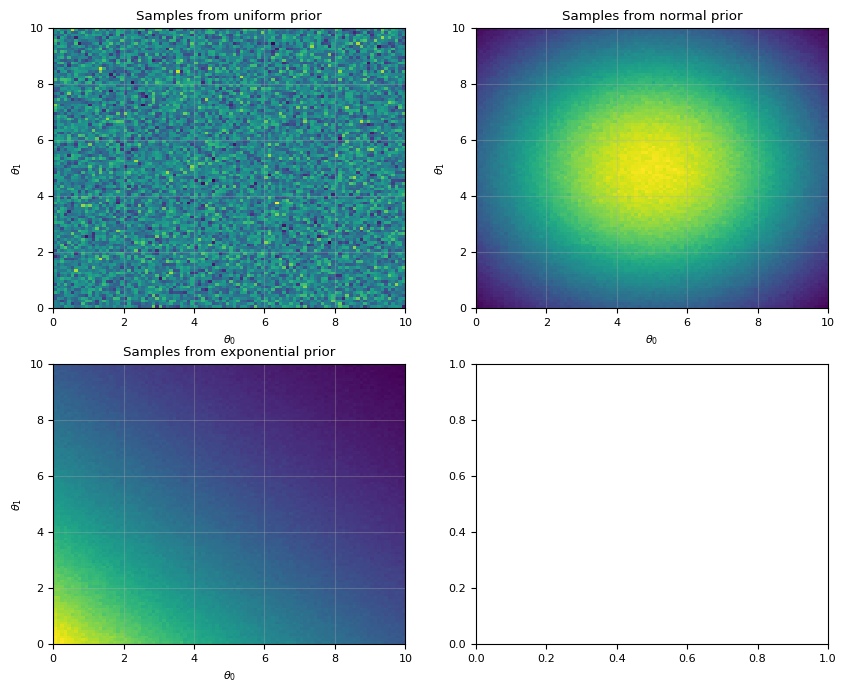

In [31]:
#2d historgrams of samples from priors
n_bins = 100
factor_n = 1_000
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]
for i, prior in enumerate(priors):
    if prior.__name__ == "uniform":
        samples = draw_uniform((factor_n*config["data"]["n_train"],))
    elif prior.__name__ == "normal":
        samples = draw_normal((factor_n*config["data"]["n_train"],))
    elif prior.__name__ == "exponential":
        samples = draw_exponential((factor_n*config["data"]["n_train"],))
    elif prior.__name__ == "grid":
        samples = draw_grid((factor_n*config["data"]["n_train"],))
    else:
        raise ValueError(f"Unknown prior: {prior.__name__}")
    
    axes[i].hist2d(samples[:, 0], samples[:, 1], bins=n_bins, range=[[param_min, param_max], [param_min, param_max]], cmap="viridis")
    axes[i].set_title(f"Samples from {prior.__name__} prior")
    axes[i].set_xlabel(r"$\theta_0$")
    axes[i].set_ylabel(r"$\theta_1$")
    axes[i].grid(alpha=0.3)
    

In [7]:
# check normalization of priors
for prior in priors:
    integral = integrate_nd_vegas(prior, [(param_min, param_max)] * config["data"]["n_parameters"], nitn=20, neval=100_000)[0]
    print(f"Integral of {prior.__name__}: {integral:.4f}")

Integral of uniform: 1.0000
Integral of normal: 1.0000
Integral of exponential: 1.0000


#### Data:

In [8]:
def draw_data(args):
    np.asarray
    shape = args.shape
    data = np.empty(shape)
    covariance = np.eye(config["data"]["n_parameters"]) * config["data"]["std_dev"]**2
    for i in range(shape[0]):
        data[i] = generator.multivariate_normal(mean=args[i], cov=covariance, size=1).squeeze()
    return data

In [9]:
def get_data(prior_sampler, config, show_output=True): #here: priors[0] = mean; priors[1] = std
    data_config = config["data"]
    total_data_points = data_config["n_train"] + data_config["n_test"] + data_config["n_validation"]
    n_class = total_data_points // 2 #data points per class

    #labels
    labels = np.hstack((np.zeros(n_class), np.ones(n_class)))

    #parameters
    parameters_all = prior_sampler((3*n_class,)) # shape=(3*n_class, n_parameters)
    parameters_A = parameters_all[:n_class,:]
    parameters_B = parameters_all[n_class:2*n_class,:]
    parameters_C = parameters_all[2*n_class:,:]
    parameters = np.vstack((parameters_A, parameters_C))

    #data
    #data_0 = draw_data(n_class, parameters_B[0,:], parameters_B[1,:])
    #data_1 = draw_data(n_class, parameters_C[0,:], parameters_C[1,:])
    data_0 = draw_data(parameters_B)
    data_1 = draw_data(parameters_C)
    data = np.vstack((data_0, data_1))

    #shuffle:
    idx = np.arange(2*(n_class))
    generator.shuffle(idx)
    data, labels, parameters = [torch.tensor(x[idx]).float() for x in (data, labels, parameters)]

    #split:
    n_train, n_test, n_validation = data_config["n_train"], data_config["n_test"], data_config["n_validation"]
    all_information = (data, labels, parameters)
    data_train, labels_train, parameters_train, = [x[:n_train] for x in all_information]
    data_test, labels_test, parameters_test, = [x[n_train:n_train+n_test] for x in all_information]
    data_validation, labels_validation, parameters_validation, = [x[n_train+n_test:n_train+n_test+n_validation] for x in all_information]

    if show_output:
        print(f"Train: {data_train.shape}, {labels_train.shape}, {parameters_train.shape}")
        print(f"Test: {data_test.shape}, {labels_test.shape}, {parameters_test.shape}")
        print(f"Validation: {data_validation.shape}, {labels_validation.shape}, {parameters_validation.shape}")
    
    return (data_train, parameters_train, labels_train), (data_validation, parameters_validation, labels_validation), (data_test, parameters_test, labels_test)

#### Training:

In [10]:
def train(model, data_train, parameters_train, labels_train, data_validation, parameters_validation, labels_validation, show_output=True):
    model.to(device)
    # Sanity checks: types, dimensions and matching lengths
    assert isinstance(data_train, torch.Tensor) and isinstance(parameters_train, torch.Tensor) and isinstance(labels_train, torch.Tensor), "data_train, parameters_train, labels_train must be torch.Tensor"
    assert data_train.shape[0] == parameters_train.shape[0] == labels_train.shape[0], "Mismatched lengths in training data"
    assert isinstance(data_validation, torch.Tensor) and isinstance(parameters_validation, torch.Tensor) and isinstance(labels_validation, torch.Tensor), "Validation tensors must be torch.Tensor"
    assert data_validation.shape[0] == parameters_validation.shape[0] == labels_validation.shape[0], "Mismatched lengths in validation data"
    
    train_dataset = torch.utils.data.TensorDataset(data_train, parameters_train, labels_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config["training"]["batch_size"], shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    criterion = nn.BCELoss()
    
    results = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_auc": []
    }
    
    for epoch in range(config["training"]["n_epochs"]):
        model.train()
        epoch_loss = 0
        for batch_data, batch_parameters, batch_labels in train_loader:
            batch_labels = batch_labels.unsqueeze(1)
            batch_labels, batch_data, batch_parameters = [x.to(device) for x in (batch_labels, batch_data, batch_parameters)]
            inputs = torch.cat((batch_data, batch_parameters), dim=1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        results["train_loss"] += [epoch_loss / len(train_loader)]
        
        model.eval()
        with torch.no_grad():
            #val_data, val_labels = [x.to(device).unsqueeze(1) for x in (data_validation, labels_validation)]
            val_labels = labels_validation.unsqueeze(1)
            val_labels, val_data, val_parameters = [x.to(device) for x in (val_labels, data_validation, parameters_validation)]
            val_inputs = torch.cat((val_data, val_parameters), dim=1)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            val_accuracy = ((val_outputs >= 0.5).float() == val_labels).float().mean()
            val_auc = roc_auc_score(val_labels.cpu(), val_outputs.cpu())

        results["val_loss"] += [val_loss.item()]
        results["val_accuracy"] += [val_accuracy.item()]
        results["val_auc"] += [val_auc]
        if show_output: print(f"Epoch {epoch+1}/{config['training']['n_epochs']}, Loss: {results['train_loss'][-1]}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_accuracy.item():.4f}, Val AUC: {val_auc:.4f}")
                
    return model, results

#### Testing:

In [11]:
def test_model(model, data_test, parameters_test, labels_test, show_output=True):
    with torch.no_grad():
        model.eval()
        labels_test = labels_test.unsqueeze(1)
        labels_test, data_test, parameters_test = [x.to(device) for x in (labels_test, data_test, parameters_test)]
        inputs = torch.cat((data_test, parameters_test), dim=1)
        outputs = model(inputs)
        test_loss = nn.BCELoss()(outputs, labels_test)
        test_accuracy = ((outputs >= 0.5).float() == labels_test).float().mean()
        test_auc = roc_auc_score(labels_test.cpu(), outputs.cpu())
        test_roc = roc_curve(labels_test.cpu(), outputs.cpu())
    if show_output: print(f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_accuracy.item():.4f}, Test AUC: {test_auc:.4f}")
    return test_loss.item(), test_accuracy.item(), test_auc, test_roc

#### Plots:

In [12]:
def plot_training_tests(training_results, test_results, prior_name, filename=None):
    plt.rcParams.update({'font.size': 8})
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    ax[0].plot(training_results["train_loss"], label="Train Loss")
    ax[0].plot(training_results["val_loss"], label="Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_ylim(0.2, 0.7)
    ax[0].set_title(f"Training Results for {prior_name} prior")
    ax[0].legend()
    ax[1].plot(training_results["val_accuracy"], label="Validation Accuracy")
    ax[1].plot(training_results["val_auc"], label="Validation AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Metric")
    ax[1].set_ylim(0.5, 1)
    ax[1].set_title(f"Training Results for {prior_name} prior")
    ax[1].legend()
    
    test_loss, test_accuracy, test_auc, test_roc = test_results
    roc_fpr, roc_tpr, thresholds = test_roc
    ax[2].plot(roc_fpr, roc_tpr, label=f"AUC = {test_auc:.4f}")
    ax[2].plot([0, 1], [0, 1], 'k--', label="Random Guess")
    ax[2].set_xlabel("False Positive Rate")
    ax[2].set_ylabel("True Positive Rate")
    ax[2].set_title(f"Test ROC Curve for {prior_name} prior")
    ax[2].legend()
    # show test_loss and test_accuracy on ax[2]
    ax[2].text(0.66, 0.22, f"Test Loss: {test_loss:.3f}\nTest Acc.: {test_accuracy:.3f}", transform=ax[2].transAxes, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="none"))
    
    plt.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        

def plot_prior_per_parameter(all_posteriors: dict, parameters_post, data_inputs, filename=None, y_label="$p(\\theta |x)$"):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(all_posteriors)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, posteriors) in enumerate(all_posteriors.items()):
        j = i // ncols
        k = i % ncols
        for posterior, data_fixed in zip(posteriors, data_inputs):
            ax[j][k].plot(parameters_post, posterior, label=f"x={data_fixed:.2f}, $x_m=${parameters_post[np.argmax(posterior)]:.2f}")
            ax[j][k].axvline(data_fixed, color='k', linestyle='--', alpha=0.5)
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("$\\theta$")
        ax[j][k].set_ylabel(y_label)
        ax[j][k].legend(loc='lower center')
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_prior_per_ratios(all_ratios: dict, parameters_post, data_inputs, filename=None, y_label="$p(x |\\theta)/p(\\theta)$"):
    plot_prior_per_parameter(all_ratios, parameters_post, data_inputs, filename, y_label)

def plot_parameter_per_prior(all_posteriors: dict, parameters_post, data_inputs, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 10})
    n_inputs = len(data_inputs)
    ncols = min(3, n_inputs)
    nrows = (n_inputs + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    #pretty = dict(zip(all_posteriors.keys(), prior_labels)) if 'prior_labels' in globals() else {k: k for k in all_posteriors}

    for i, x0 in enumerate(data_inputs):
        a = axes[i]
        for prior_name, posts in all_posteriors.items():
            p = posts[i]
            x_map = parameters_post[np.argmax(p)]
            a.plot(parameters_post, p, label=f"{all_posteriors[prior_name]} (MAP={x_map:.2f})")
        a.axvline(x0, color='k', linestyle='--', alpha=0.5)
        a.set_title(f"x = {x0:.2f}")
        a.set_xlabel("$\\theta$")
        a.set_ylabel("$p(\\theta\\mid x)$")
        a.grid(True)
        a.legend(loc='lower center')

    for k in range(n_inputs, nrows * ncols):
        fig.delaxes(axes[k])
        
    if filename is not None:
        fig.savefig(filename)    

def plot_error_and_hpd_width(HPDs: dict, data_inputs, all_posteriors, parameters_post, priors, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(HPDs)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7*ncols, 4*nrows))
    
    for i, (prior_name, errors) in enumerate(HPDs.items()):
        j = i // ncols
        k = i % ncols
        
        # Get the corresponding prior function
        prior_func = priors[i]
        
        # MAP estimates from the posteriors for this prior
        posts = all_posteriors[prior_name]
        y_hat = np.asarray([parameters_post[np.argmax(p)] for p in posts])
        
        # Calculate absolute errors: |y_hat - x_true|
        abs_errors = y_hat - np.asarray(data_inputs)
        
        # Calculate 68% HPD widths
        widths68 = []
        def pick_interval(intervals, yh):
            if intervals is None or len(intervals) == 0:
                return np.array([yh, yh])
            intervals = np.atleast_2d(intervals)
            mask = (intervals[:, 0] <= yh) & (yh <= intervals[:, 1])
            if np.any(mask):
                return intervals[np.where(mask)[0][0]]
            mids = 0.5 * (intervals[:, 0] + intervals[:, 1])
            idx_min = np.argmin(np.abs(mids - yh))
            return intervals[idx_min]
        
        for idx, e in enumerate(errors):
            yh = y_hat[idx]
            low68, high68 = pick_interval(e["68"], yh)
            widths68.append(high68 - low68)
        
        # Create twin axes for different y-scales
        ax1 = ax[j][k]
        ax2 = ax1.twinx()
        
        # Plot prior distribution in the background (on ax1)
        prior_vals = prior_func(parameters_post)
        ax1.fill_between(parameters_post, prior_vals, alpha=0.2, color='gray', label='$p(\\theta)$')
        ax1.set_ylabel('Prior $p(\\theta)$', color='gray')
        ax1.tick_params(axis='y', labelcolor='gray')
        
        # Plot absolute error (on ax2)
        line1 = ax2.plot(data_inputs, abs_errors, 'o-', color='C0', label='$\\delta$', markersize=8)
        
        # Plot 68% HPD width (on ax2)
        line2 = ax2.plot(data_inputs, widths68, 's-', color='C1', label='$\\Delta_\\alpha$', markersize=8)
        
        ax2.set_ylabel('Error $\\delta$ / HPD $\\Delta_\\alpha$', color='black')
        ax2.set_ylim(-1.5, 2.5)
        ax2.tick_params(axis='y', labelcolor='black')
        
        # Set title and labels
        ax1.set_title(f"{prior_name} prior")
        ax1.set_xlabel("True $\\theta$")
        ax1.grid(True, alpha=0.3)
        
        # Combine legends from both axes
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax2.legend(lines, labels, loc='center right')
        
        # Add prior to the legend manually
        #ax1.legend(loc='center left')
    
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    
    fig.tight_layout()
    
    if filename is not None:
        fig.savefig(filename)


def plot_ratio_violins(all_ratios, test_parameters, filename=None):
    plt.rcParams.update({'font.size': 10})
    n_priors = len(all_ratios)
    ncols = 3
    nrows = (n_priors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    positions = np.arange(len(test_parameters))

    for i, (prior_name, ratio_distributions) in enumerate(all_ratios.items()):
        a = axes[i]
        parts = a.violinplot(ratio_distributions, positions=positions, showmeans=True, showextrema=True, widths=0.8)
        a.set_xticks(positions)
        a.set_xticklabels([f"{tp:.2f}" for tp in test_parameters])
        a.set_title(f"{prior_name} prior")
        a.set_xlabel(r"parameter $\theta_0$")
        a.set_ylabel(r"$r(x|\theta_0)=p(x|\theta_0)/p(x)$")
        a.set_ylim(0, 5)
        a.grid(alpha=0.3)

        means = [np.mean(d) if len(d) else np.nan for d in ratio_distributions]
        for pos, m in enumerate(means):
            if np.isfinite(m):
                y_top = a.get_ylim()[1]
                y_text = min(m * 1.05, 0.95 * y_top)
                a.text(pos, y_text, f"μ={m:.3g}", ha="center", va="bottom", fontsize=9)

    for k in range(n_priors, nrows * ncols):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameters, n_bins, filename=None):
    x_all = np.concatenate([np.asarray(data_x[0]).ravel(), np.asarray(data_x[1]).ravel()])
    x_min, x_max = x_all.min(), x_all.max()

    ncols = 3
    nrows = (len(priors) + ncols - 1) // ncols
    plt.rcParams.update({'font.size': 10})
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    for i, prior in enumerate(priors):
        a = axes[i]
        a.hist(data_x[0], bins=n_bins, density=False, alpha=0.45, label=f"x|θ={test_parameters[0]}", color="C0")
        a.hist(data_x[1], bins=n_bins, density=False, alpha=0.45, label=f"x|θ={test_parameters[1]}", color="C1")

        centers, rw_density = reweighted_distributions[prior.__name__]
        a.plot(centers, rw_density, drawstyle="steps-mid", lw=1, color="C3", label=f"reweighted θ={test_parameters[0]}→{test_parameters[1]}")

        a.set_title(f"{prior.__name__} prior")
        a.set_xlabel("x")
        a.set_ylabel("Density")
        a.set_xlim(x_min, x_max)
        a.grid(alpha=0.3)
        a.legend()

    for k in range(len(priors), nrows * ncols):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename:
        fig.savefig(filename)
        
def plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=None):
    x0 = np.asarray(data_x[0])
    x1 = np.asarray(data_x[1])

    overlaps = {}
    for prior in priors:
        w = np.asarray(reweighting_distributions[prior.__name__])

        mask = np.isfinite(x0) & np.isfinite(w)
        x0_f = x0[mask]
        w_f = w[mask]

        hist_q, edges = np.histogram(x0_f, bins=n_bins, weights=w_f, density=False)
        hist_r, _     = np.histogram(x1,   bins=edges, density=False)
        bin_widths = np.diff(edges)

        overlap = float(np.sum(np.minimum(hist_q, hist_r) * bin_widths))
        overlaps[prior.__name__] = overlap
        
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(overlaps.keys(), overlaps.values(), color=plt.get_cmap('Set1').colors[:len(overlaps.values())], alpha=0.8)
    ax.set_ylim(0.5, 1)
    ax.set_ylabel("Overlap integral")
    ax.set_title("overlap integrals between $p(x|\\theta_2)$ and reweighted $p(x|\\theta_1)$ across priors")
    ax.grid(axis='y', alpha=0.3)

    for b, v in zip(bars, overlaps.values()):
        ax.annotate(f"{v:.3f}", xy=(b.get_x() + b.get_width() / 2, v),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    if filename:
        fig.savefig(filename)
    return overlaps

def plot_all_outs_histograms(all_outs, parameter_labels, n_bins, filename=None):
    prior_keys = list(all_outs.keys())
    n_priors = len(prior_keys)

    ncols=3
    nrows = (n_priors + ncols - 1) // ncols
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", [])
    if len(colors) < len(parameter_labels):
        # repeat colors if needed
        rep = (len(parameter_labels) + len(colors) - 1) // len(colors)
        colors = (colors * rep)[:len(parameter_labels)]

    for i, prior_key in enumerate(prior_keys):
        a = axes[i]
        components = all_outs[prior_key]
        for j, arr in enumerate(components):
            label = f"y|θ={parameter_labels[j]}"
            a.hist(
                arr,
                bins=n_bins,
                density=True,
                alpha=.5,
                color=colors[j],
                label=label
            )
        a.set_title(prior_keys[i])
        a.set_xlabel("Model output")
        a.set_ylabel("Density")
        a.set_xlim(0, 1)
        a.grid(alpha=0.3)
        a.legend(frameon=False, fontsize=9)

    # remove extra axes
    for k in range(n_priors, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename:
        fig.savefig(str(filename), dpi=150)

    return fig, axes

def plot_all_rocs(test_results, filename=None):
    """
    Plot all ROC curves from test_results (list of dicts or a single dict).
    Each curve corresponds to one prior combination; legend includes AUC.
    """
    # Normalize input to an iterable of (name, result) pairs
    def _iter_results(tr):
        if isinstance(tr, dict):
            for k, v in tr.items():
                yield k, v
        else:
            for d in tr:
                for k, v in d.items():
                    yield k, v

    # Collect curves first so we can sort by AUC for a cleaner legend
    curves = []
    for name, res in _iter_results(test_results):
        if res is None or len(res) < 4:
            continue
        try:
            auc = float(res[2])
            fpr, tpr, _ = res[3]
            curves.append((auc, fpr, tpr, name))
        except Exception:
            continue

    if not curves:
        print("No valid ROC data found in test_results.")
        return

    curves.sort(key=lambda x: x[0], reverse=True)

    plt.figure(figsize=(8, 6))
    for auc, fpr, tpr, name in curves:
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.5, alpha=0.9)

    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC curves across prior combinations")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150)

def plot_auc_matrix(test_results, priors0, priors1, filename=None):
    # Helper: iterate dicts
    def _iter_results(tr):
        if isinstance(tr, dict):
            yield tr
        else:
            for d in tr:
                yield d

    row_names = [p.__name__ for p in priors0]
    col_names = [p.__name__ for p in priors1]

    mat = np.full((len(row_names), len(col_names)), np.nan, dtype=float)

    # collect AUCs per cell across iterations (if any)
    for i, r in enumerate(row_names):
        for j, c in enumerate(col_names):
            key = f"{r}_{c}"
            aucs = []
            for d in _iter_results(test_results):
                val = d.get(key)
                if val is None or len(val) < 3:
                    continue
                try:
                    aucs.append(float(val[2]))
                except Exception:
                    pass
            if aucs:
                mat[i, j] = np.mean(aucs)

    # color scaling
    finite_vals = mat[np.isfinite(mat)]    
    vmin = float(np.nanmin(finite_vals))
    vmax = float(np.nanmax(finite_vals))

    fig, ax = plt.subplots(figsize=(1.2 * len(col_names) + 2, 1.0 * len(row_names) + 2))
    im = ax.imshow(mat, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")

    # ticks and labels
    ax.set_xticks(np.arange(len(col_names)))
    ax.set_yticks(np.arange(len(row_names)))
    ax.set_xticklabels(col_names, rotation=45, ha="right")
    ax.set_yticklabels(row_names)
    ax.set_xlabel("Parameter 1 prior")
    ax.set_ylabel("Parameter 0 prior")
    ax.set_title("AUC matrix by prior combination")

    # annotations
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isfinite(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", color="w", fontsize=9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("AUC", rotation=90)

    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150)
    return fig, ax

def plot_all_posteriors_contour(all_posteriors, inference_data, priors0, priors1, all_parameters_in_range, i_combination=200, zoom_factor=[0.2, 0.05], filename=None):
    """
    Plot all posterior distributions as contour plots arranged in a grid.
    
    Parameters:
    - all_posteriors: dict with keys like "prior0_prior1" containing posterior arrays
    - inference_data: tuple containing (parameters_to_infer, parameter_combinations, sampled_data)
    - priors0: list of prior functions for parameter 0
    - priors1: list of prior functions for parameter 1
    - all_parameters_in_range: list of arrays [theta0_range, theta1_range]
    - zoom_factor: list or tuple with zoom factors for each parameter
    - filename: optional filename to save the figure
    """
    parameters_to_infer, parameter_combinations, sampled_data = inference_data

    # Calculate zoom range around the inference point
    zoom_limits = None
    if len(parameter_combinations) > 0:
        param_comb = parameter_combinations[i_combination]
               
        # Calculate ranges for each parameter
        theta0_min, theta0_max = all_parameters_in_range[0][0], all_parameters_in_range[0][-1]
        theta1_min, theta1_max = all_parameters_in_range[1][0], all_parameters_in_range[1][-1]
        
        range0 = theta0_max - theta0_min
        range1 = theta1_max - theta1_min
        
        # Set zoom limits
        theta0_zoom_min = max(theta0_min, param_comb[0] - zoom_factor[0] * range0)
        theta0_zoom_max = min(theta0_max, param_comb[0] + zoom_factor[0] * range0)
        theta1_zoom_min = max(theta1_min, param_comb[1] - zoom_factor[1] * range1)
        theta1_zoom_max = min(theta1_max, param_comb[1] + zoom_factor[1] * range1)
        
        zoom_limits = (theta0_zoom_min, theta0_zoom_max, theta1_zoom_min, theta1_zoom_max)
    
    n_priors0 = len(priors0)
    n_priors1 = len(priors1)
    
    plt.rcParams.update({'font.size': 10})
    fig, axes = plt.subplots(n_priors0, n_priors1, figsize=(5 * n_priors1, 4 * n_priors0))
    
    # Ensure axes is always 2D array
    if n_priors0 == 1 and n_priors1 == 1:
        axes = np.array([[axes]])
    elif n_priors0 == 1:
        axes = axes.reshape(1, -1)
    elif n_priors1 == 1:
        axes = axes.reshape(-1, 1)
    
    theta0_range = all_parameters_in_range[0]
    theta1_range = all_parameters_in_range[1]
    
    for i, prior0 in enumerate(priors0):
        for j, prior1 in enumerate(priors1):
            ax = axes[i, j]
            prior_name = f"{prior0.__name__}_{prior1.__name__}"
            
            # Get the posterior (take first one if multiple exist)
            posterior = all_posteriors[prior_name][i_combination]
            
            # Reshape to 2D grid if needed
            if posterior.ndim == 1:
                Z = to_grid(posterior, [theta0_range, theta1_range])
            else:
                Z = posterior
            
            # Create meshgrid - swap X and Y to match grid arrangement
            Y, X = np.meshgrid(theta0_range, theta1_range, indexing='ij')
            
            # Plot contour with transposed Z
            cf = ax.contourf(X, Y, Z.T, levels=30, cmap='viridis')
            ax.contour(X, Y, Z.T, levels=10, colors='k', linewidths=0.5, alpha=0.4)
            
            # Plot the inferred data point (parameter combination) - swap coordinates
            if len(parameter_combinations) > 0:
                param_comb = parameter_combinations[i_combination]
                ax.plot(param_comb[1], param_comb[0], 'ro', markersize=5, 
                       markeredgewidth=1.5,
                       label=f'target θ=({param_comb[0]:.2f}, {param_comb[1]:.3f})')
                ax.legend(loc='upper right', fontsize=8)
            
            # Apply zoom limits - swap x and y limits
            if zoom_limits is not None:
                ax.set_xlim(zoom_limits[2], zoom_limits[3])
                ax.set_ylim(zoom_limits[0], zoom_limits[1])
            
            # Set labels - swap labels
            ax.set_xlabel('$\\theta_1$')
            ax.set_ylabel('$\\theta_0$')
            
            # Add prior names to outer edges
            if i == 0:
                ax.set_title(f'{prior1.__name__}', fontsize=12)
            if j == 0:
                ax.text(-0.3, 0.5, f'{prior0.__name__}', 
                       transform=ax.transAxes, fontsize=12,
                       rotation=90, va='center', ha='center')
            
            ax.grid(alpha=0.3)
            
            # Add colorbar
            plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    
    # Add overall axis labels
    fig.text(0.5, 0.02, 'Parameter 1 Prior', ha='center', fontsize=14)
    fig.text(0.02, 0.5, 'Parameter 0 Prior', va='center', rotation='vertical', 
             fontsize=14)
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
    
    if filename:
        fig.savefig(filename, bbox_inches='tight')
        
def plot_errorbars(HPDs: dict, inference_data, all_posteriors, parameters_post, show_annotations=True, filename=None):
    # inference_data = (parameters_to_infer, parameter_combinations, sampled_data)
    _, parameter_combinations, _ = inference_data
    true_params = np.asarray(parameter_combinations, dtype=float)  # shape (N, n_dims)

    n_dims = len(parameters_post)
    n_posteriors = len(HPDs)

    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=n_posteriors, ncols=n_dims, figsize=(5 * n_dims, 3.8 * n_posteriors), squeeze=False)

    dim_lengths = [len(r) for r in parameters_post]

    def _get_bounds(interval, yh):
        # Robustly return (low, high) for one dimension; fall back to point if malformed
        try:
            arr = np.asarray(interval, dtype=float)
        except Exception:
            return yh, yh
        if arr.ndim == 1 and arr.size == 2:
            return float(arr[0]), float(arr[1])
        if arr.ndim == 2 and arr.shape[1] == 2:
            mask = (arr[:, 0] <= yh) & (yh <= arr[:, 1])
            if np.any(mask):
                row = arr[np.where(mask)[0][0]]
            else:
                mids = 0.5 * (arr[:, 0] + arr[:, 1])
                row = arr[np.argmin(np.abs(mids - yh))]
            return float(row[0]), float(row[1])
        return yh, yh

    for i, (prior_name, errors) in enumerate(HPDs.items()):
        posts = all_posteriors[prior_name]  # list length N, each is flattened posterior over grid
        N = len(posts)

        # MAP estimates per posterior, per dimension
        y_hat = np.zeros((N, n_dims), dtype=float)
        for idx, p in enumerate(posts):
            arr = np.asarray(p)
            if arr.ndim == 1:
                imax = int(np.argmax(arr))
                multi = np.unravel_index(imax, dim_lengths)
            else:
                multi = np.unravel_index(int(np.argmax(arr)), arr.shape)
            for d in range(n_dims):
                y_hat[idx, d] = parameters_post[d][multi[d]]

        # Filter: nur Punkte mit festem Wert der anderen Dimension zeichnen
        for d in range(n_dims):
            x_true_all = true_params[:, d]
            y_est_all  = y_hat[:, d]
            other_dim = 1 - d
            other_vals = true_params[:, other_dim]
            unique_other = np.unique(other_vals)
            anchor = unique_other[len(unique_other)//2]  # z.B. mittlerer Wert der anderen Dimension
            mask = np.isclose(other_vals, anchor)

            x_true = x_true_all[mask]
            y_est  = y_est_all[mask]
            errors_f = [e for m, e in zip(mask, errors) if m]

            yerr68_lower, yerr68_upper = [], []
            yerr95_lower, yerr95_upper = [], []
            widths68 = []

            for idx, e in enumerate(errors_f):
                yh = y_est[idx]
                low68, high68 = _get_bounds(e["68"][d], yh)
                low95, high95 = _get_bounds(e["95"][d], yh)
                yerr68_lower.append(abs(yh - low68))
                yerr68_upper.append(abs(high68 - yh))
                yerr95_lower.append(abs(yh - low95))
                yerr95_upper.append(abs(high95 - yh))
                widths68.append(high68 - low68)

            yerr68 = np.vstack([yerr68_lower, yerr68_upper]) if len(yerr68_lower) else np.zeros((2,0))
            yerr95 = np.vstack([yerr95_lower, yerr95_upper]) if len(yerr95_lower) else np.zeros((2,0))

            a = ax[i, d]
            a.errorbar(x_true, y_est, yerr=yerr95, fmt='o', color='C0', ecolor='C0', alpha=0.35, capsize=5, label="95% HPD")
            a.errorbar(x_true, y_est, yerr=yerr68, fmt='o', color='C0', ecolor='C0', capsize=5, label="68% HPD")

            abs_errors = y_est - x_true
            if show_annotations:
                for xt, ye, w, eabs in zip(x_true, y_est, widths68, abs_errors):
                    a.annotate(rf"$\delta$={eabs:.2f}"+"\n"+rf"$\Delta$={w:.2f}",
                            xy=(xt, ye), xytext=(6, -22), textcoords="offset points",
                            ha='left', va='bottom', fontsize=10, color='C0')

            tmin, tmax = parameters_post[d][0], parameters_post[d][-1]
            a.plot([tmin, tmax], [tmin, tmax], 'k--', label="Ideal")
            a.set_title(f"{prior_name} prior (θ_{d})")
            a.set_xlabel(f"True $\\theta_{d}$")
            a.set_ylabel(f"Estimated $\\theta_{d}$")
            a.grid()
            a.legend()

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_error_and_hpd_width(HPDs: dict, inference_data, all_posteriors, parameters_post, priors_unused=None, filename=None):
    # inference_data = (parameters_to_infer, parameter_combinations, sampled_data)
    _, parameter_combinations, _ = inference_data
    true_params = np.asarray(parameter_combinations, dtype=float)  # shape (N, n_dims)

    n_dims = len(parameters_post)
    n_posteriors = len(HPDs)

    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=n_posteriors, ncols=n_dims, figsize=(6.5 * n_dims, 3.8 * n_posteriors), squeeze=False)

    dim_lengths = [len(r) for r in parameters_post]

    # Map prior_name -> (prior0_func, prior1_func) from priors0/priors1 by name
    def _get_prior_funcs(prior_name):
        try:
            name0, name1 = prior_name.split("_", 1)
        except Exception:
            return None, None
        p0 = next((p for p in priors0 if getattr(p, "__name__", "") == name0), None)
        p1 = next((p for p in priors1 if getattr(p, "__name__", "") == name1), None)
        return p0, p1

    def _get_bounds(interval, yh):
        # Robustly return (low, high) for one dimension; fall back to point if malformed
        try:
            arr = np.asarray(interval, dtype=float)
        except Exception:
            return yh, yh
        if arr.ndim == 1 and arr.size == 2:
            return float(arr[0]), float(arr[1])
        if arr.ndim == 2 and arr.shape[1] == 2:
            mask = (arr[:, 0] <= yh) & (yh <= arr[:, 1])
            if np.any(mask):
                row = arr[np.where(mask)[0][0]]
            else:
                mids = 0.5 * (arr[:, 0] + arr[:, 1])
                row = arr[np.argmin(np.abs(mids - yh))]
            return float(row[0]), float(row[1])
        return yh, yh

    for i, (prior_name, errors) in enumerate(HPDs.items()):
        posts = all_posteriors[prior_name]  # list length N, each flattened posterior over grid
        N = len(posts)

        # MAP estimates per posterior, per dimension
        y_hat = np.zeros((N, n_dims), dtype=float)
        for idx, p in enumerate(posts):
            arr = np.asarray(p)
            if arr.ndim == 1:
                imax = int(np.argmax(arr))
                multi = np.unravel_index(imax, dim_lengths)
            else:
                multi = np.unravel_index(int(np.argmax(arr)), arr.shape)
            for d in range(n_dims):
                y_hat[idx, d] = parameters_post[d][multi[d]]

        # Prior funcs for background
        pf0, pf1 = _get_prior_funcs(prior_name)
        pf_by_dim = [pf0, pf1]

        for d in range(n_dims):
            x_true_all = true_params[:, d]
            y_est_all  = y_hat[:, d]
            other_dim  = 1 - d
            other_vals = true_params[:, other_dim]
            unique_other = np.unique(other_vals)
            anchor = unique_other[len(unique_other)//2]  # middle value of the other dimension
            mask = np.isclose(other_vals, anchor)

            x_true = x_true_all[mask]
            y_est  = y_est_all[mask]
            errors_f = [e for m, e in zip(mask, errors) if m]

            # 68% HPD widths for dimension d
            widths68 = []
            for idx, e in enumerate(errors_f):
                yh = y_est[idx]
                low68, high68 = _get_bounds(e["68"][d], yh)
                widths68.append(high68 - low68)

            abs_errors = y_est - x_true

            a1 = ax[i, d]
            a2 = a1.twinx()

            # Prior background (if available)
            pf = pf_by_dim[d]
            if pf is not None:
                prior_vals = pf(parameters_post[d])
                a1.fill_between(parameters_post[d], prior_vals, alpha=0.2, color='gray', label='$p(\\theta_{%d})$' % d)
                a1.set_ylabel('Prior $p(\\theta_{%d})$' % d, color='gray')
                a1.tick_params(axis='y', labelcolor='gray')

            # Error and HPD width vs true parameter
            line1 = a2.plot(x_true, abs_errors, 'o-', color='C0', label='$\\delta$', markersize=6)
            line2 = a2.plot(x_true, widths68, 's-', color='C1', label='$\\Delta_{68\\%}$', markersize=6)

            a2.set_ylabel('Error $\\delta$ / HPD width', color='black')
            a2.tick_params(axis='y', labelcolor='black')

            # Titles, labels, legend
            a1.set_title(f"{prior_name} prior (θ_{d})")
            a1.set_xlabel(f"True $\\theta_{d}$")
            a1.grid(True, alpha=0.3)

            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            a2.legend(lines, labels, loc='best', fontsize=9)

    fig.tight_layout()
    if filename:
        fig.savefig(filename)

#### Run:

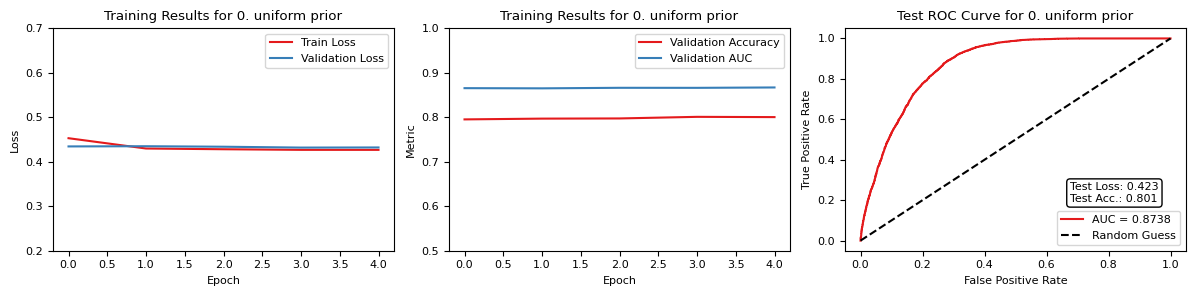

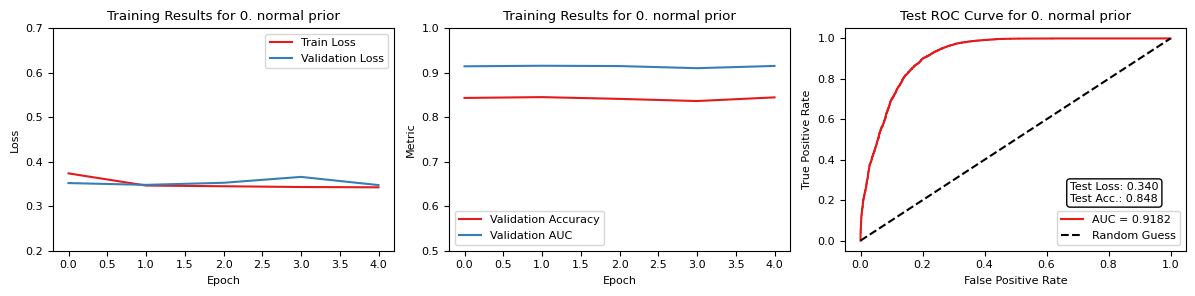

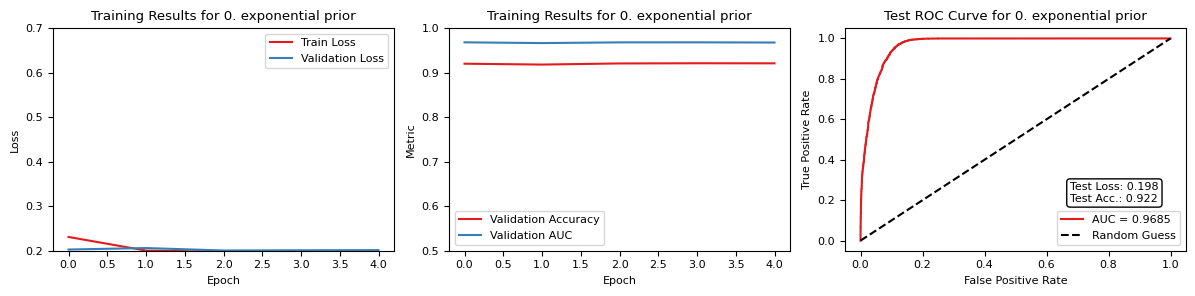

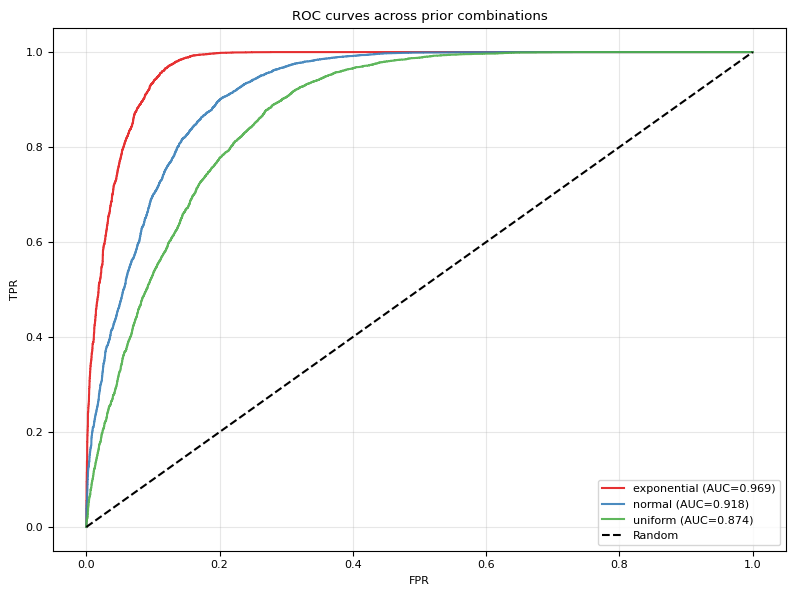

In [14]:
models = [{} for _ in range(config["training"]["model_iterations"])]
test_results = [{} for _ in range(config["training"]["model_iterations"])]
for prior_sampler in prior_samplers:
        priors_names = f"{prior_sampler.__name__}"
        for i in range(config["training"]["model_iterations"]):
            train_set, validation_set, test_set = get_data(prior_sampler, config, show_output=False)
            model = BinaryClassifier(config)
            model, training_results = train(model, *train_set, *validation_set, show_output=False)
            filename_plots = get_filepath(f"training/training_{i}/training_{priors_names}_prior.svg", config)
            filename_model = get_filepath(f"models/models_{i}/model_{priors_names}_prior.pth", config)
            torch.save(model.state_dict(), filename_model)
            test_result = test_model(model, *test_set, show_output=False)
            plot_training_tests(training_results, test_result, f"{i}. {priors_names}", filename_plots)
            models[i][priors_names] = model
            test_results[i][priors_names] = test_result
plot_all_rocs(test_results, filename=get_filepath("training/all_roc_curves.svg", config))

#### Posterior:

In [15]:
def _to_1d_torch_grid(x, device, dtype):
    t = torch.as_tensor(np.asarray(x), device=device, dtype=dtype)
    if t.ndim != 1:
        raise ValueError("Each entry in x_range must be a 1D array.")
    if t.numel() < 2:
        raise ValueError("Each axis in x_range must contain at least 2 points.")
    return t

def integrate_nD(fct, x_range):
    """
    Perform numerical integration of a function over n dimensions using the trapezoidal rule.

    Parameters:
    - fct: n-dimensional array of function values at the grid points
    - x_range: list of numpy arrays, each produced by np.linspace for each dimension

    Returns:
    - Numerical integral of the function
    """
    result = fct
    for i in range(len(x_range) - 1, -1, -1):
        result = np.trapezoid(result, x_range[i], axis=i)
    return result

def integrate_nD_qmc_torch(
    fct_or_values,
    x_range,
    n_samples=2**18,
    batch_size=2**16,
    device=None,
    sobol_scramble=True,
    seed=0,
    use_float64=False,
    return_stderr=True,
):
    """
    QMC integration on CPU/GPU using Sobol points.

    Supports:
      1) callable integrand: f(x) where x has shape (N, D)
      2) tabulated integrand values on a regular grid (nearest-neighbor lookup)

    Args:
        fct_or_values: callable or ndarray with shape [len(r) for r in x_range]
        x_range: list of 1D arrays for each axis
        n_samples: total number of Sobol points
        batch_size: Sobol batch size for evaluation
        device: torch device string (e.g. "cuda" / "cpu")
        sobol_scramble: whether to scramble Sobol sequence
        seed: seed for SobolEngine
        use_float64: use float64 for coordinates/evaluation
        return_stderr: return (estimate, stderr) if True, else estimate only

    Returns:
        integral estimate (and stderr if return_stderr=True)
    """
    if n_samples <= 0:
        raise ValueError("n_samples must be positive.")
    if batch_size <= 0:
        raise ValueError("batch_size must be positive.")

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)
    dtype = torch.float64 if use_float64 else torch.float32

    d = len(x_range)
    if d == 0:
        raise ValueError("x_range must contain at least one dimension.")

    x_t = [_to_1d_torch_grid(x, device=device, dtype=dtype) for x in x_range]
    lows = torch.stack([x[0] for x in x_t])
    highs = torch.stack([x[-1] for x in x_t])
    widths = highs - lows
    if torch.any(widths <= 0):
        raise ValueError("Each axis in x_range must be strictly increasing.")

    volume = torch.prod(widths.to(torch.float64))
    if not torch.isfinite(volume):
        raise FloatingPointError("Integration volume overflowed; check bounds or use log-domain scaling.")

    if callable(fct_or_values):
        def eval_fn(points):
            vals = fct_or_values(points)
            if isinstance(vals, np.ndarray):
                vals = torch.from_numpy(vals)
            vals = torch.as_tensor(vals, device=device)
            return vals.reshape(-1)
    else:
        y = torch.as_tensor(np.asarray(fct_or_values), device=device, dtype=dtype).contiguous()
        expected_shape = tuple(len(x) for x in x_range)
        if tuple(y.shape) != expected_shape:
            raise ValueError(
                f"fct shape {tuple(y.shape)} does not match expected grid shape {expected_shape}."
            )

        y_flat = y.reshape(-1)
        strides = []
        running = 1
        for size in reversed(expected_shape[1:]):
            running *= size
            strides.append(running)
        strides = [1] + strides
        strides = torch.as_tensor(list(reversed(strides)), device=device, dtype=torch.long)

        def eval_fn(points):
            lin_idx = torch.zeros(points.shape[0], device=device, dtype=torch.long)
            for dim, axis in enumerate(x_t):
                points_dim = points[:, dim].contiguous()
                idx_right = torch.searchsorted(axis, points_dim, right=False)
                idx_right = torch.clamp(idx_right, 0, axis.numel() - 1)
                idx_left = torch.clamp(idx_right - 1, 0, axis.numel() - 1)

                dist_left = torch.abs(points_dim - axis[idx_left])
                dist_right = torch.abs(axis[idx_right] - points_dim)
                idx = torch.where(dist_left <= dist_right, idx_left, idx_right)

                lin_idx = lin_idx + idx * strides[dim]
            return y_flat[lin_idx]

    sobol = torch.quasirandom.SobolEngine(dimension=d, scramble=sobol_scramble, seed=seed)

    n_done = 0
    sum_vals = torch.tensor(0.0, device=device, dtype=torch.float64)
    sum_sq_vals = torch.tensor(0.0, device=device, dtype=torch.float64)

    while n_done < n_samples:
        n_batch = min(batch_size, n_samples - n_done)
        u = sobol.draw(n_batch).to(device=device, dtype=dtype)
        pts = lows + u * widths
        vals = eval_fn(pts).to(torch.float64)

        sum_vals += torch.sum(vals)
        sum_sq_vals += torch.sum(vals * vals)
        n_done += n_batch

    mean = sum_vals / n_samples
    integral = volume * mean

    if return_stderr:
        var = torch.clamp(sum_sq_vals / n_samples - mean * mean, min=0.0)
        stderr = volume * torch.sqrt(var / n_samples)
        return float(integral.item()), float(stderr.item())

    return float(integral.item())

def integrate_nD_auto(fct_or_values, x_range, method="auto", qmc_threshold_dim=8, **qmc_kwargs):
    """
    Drop-in wrapper to select between trapezoid and QMC.

    - method="trapz": original integrate_nD
    - method="qmc": CUDA/CPU Sobol QMC
    - method="auto": QMC for callable or high-D tabulated integrands
    """
    if method == "trapz":
        if callable(fct_or_values):
            raise TypeError("integrate_nD (trapz) expects tabulated values, not callable.")
        return integrate_nD(fct_or_values, x_range)

    if method == "qmc":
        return integrate_nD_qmc_torch(fct_or_values, x_range, **qmc_kwargs)

    if method == "auto":
        if callable(fct_or_values) or len(x_range) >= qmc_threshold_dim:
            return integrate_nD_qmc_torch(fct_or_values, x_range, **qmc_kwargs)
        if callable(fct_or_values):
            raise TypeError("Trapz path expects tabulated values.")
        return integrate_nD(fct_or_values, x_range)

    raise ValueError("method must be one of {'auto', 'trapz', 'qmc'}")

In [16]:
def to_grid(arr, x_ranges):
    return arr.reshape([len(r) for r in x_ranges])

def create_inference_parameters(n_parameters_to_infer, parameters_min_max, margin=1/4, data_is_random=False):
    parameter_min, parameter_max = parameters_min_max
    parameter_range = parameter_max - parameter_min
    if data_is_random:
        parameters_to_infer = generator.uniform(
            low=parameter_min+parameter_range*margin,
            high=parameter_max-parameter_range*margin,
            size=n_parameters_to_infer
        )
    else:
        parameters_to_infer = np.linspace(
            parameter_min + parameter_range * margin,
            parameter_max - parameter_range * margin,
            n_parameters_to_infer,
        )
    return parameters_to_infer

def create_inference_data(parameters_min_max, n_parameters_to_infer_per_dim=5, margin=1/4, data_is_random=False, n_repititions_per_parameter=1, parameters_to_infer=None):
    n_dimensions = config["data"]["n_parameters"]
    
    if parameters_to_infer is None:
        parameters_to_infer = []
        for _ in range(n_dimensions):
            parameters_to_infer += [create_inference_parameters(
                n_parameters_to_infer_per_dim, parameters_min_max, margin, data_is_random
            )]

    sampled_data = []
    parameter_combinations = list(itertools.product(*parameters_to_infer))
    for parameter_combination in parameter_combinations:
        sampled_data += [draw_data(np.asarray(
            [parameter_combination for _ in range(n_repititions_per_parameter)]
        ))]
    sampled_data = np.asarray(sampled_data)

    return parameters_to_infer, parameter_combinations, sampled_data

def area_above_k(k, x_range, posterior_normalized):
    """
    Compute the area where posterior >= k for n-dimensional distributions.
    
    Parameters:
    - k: threshold value
    - x_range: list of numpy arrays for each dimension
    - posterior_normalized: n-dimensional array of posterior values
    
    Returns:
    - Area (integral) above threshold k
    """
    mask = posterior_normalized >= k
    if not np.any(mask):
        return 0.0
    masked_posterior = np.where(mask, posterior_normalized, 0.0)
    area = integrate_nD_auto(to_grid(masked_posterior, x_range), x_range, method="qmc")
    return area

def compute_hpd_interval(x_range, posterior_normalized, alpha):
    """
    Compute HPD interval for n-dimensional posterior distributions.
    
    Parameters:
    - x_range: list of numpy arrays for each dimension
    - posterior_normalized: n-dimensional array of posterior values
    - alpha: credible level (e.g., 0.32 for 68%, 0.05 for 95%)
    
    Returns:
    - intervals_per_dim: array of intervals for each dimension
      [[dim0_low, dim0_high], [dim1_low, dim1_high], ...]
    - interval_combined: [avg_low, avg_high] where:
      avg_low = mean of per-dimension low bounds
      avg_high = mean of per-dimension high bounds
    """
    if posterior_normalized.ndim == 1:
        posterior_normalized = to_grid(posterior_normalized, x_range)
    
    def root_func(k):
        return area_above_k(k, x_range, posterior_normalized) - (1 - alpha)
    
    p_min = np.min(posterior_normalized)
    p_max = np.max(posterior_normalized)
    
    k_lower = p_min
    k_upper = p_max
    
    func_lower = root_func(k_lower)
    func_upper = root_func(k_upper)
    
    if func_lower < 0 or func_upper > 0:
        raise ValueError("Cannot find a valid k in the given range. Check the posterior and alpha.")
    
    k = brentq(root_func, k_lower, k_upper, xtol=1e-12)
    mask = posterior_normalized >= k
    
    n_dims = len(x_range)
    intervals_list = []
    
    for dim in range(n_dims):
        axes_to_reduce = tuple(i for i in range(n_dims) if i != dim)
        marginalized_mask = np.any(mask, axis=axes_to_reduce)
        
        indices = np.where(marginalized_mask)[0]
        theta = x_range[dim]
        
        intervals = []
        if indices.size > 0:
            breaks = np.where(np.diff(indices) > 1)[0]
            start_idx = 0
            breaks = np.append(breaks, len(indices) - 1)
            for break_idx in breaks:
                idx_range = indices[start_idx:break_idx + 1]
                theta_start = theta[idx_range[0]]
                theta_end = theta[idx_range[-1]]
                intervals.append([theta_start, theta_end])
                start_idx = break_idx + 1
        
        if intervals:
            intervals_list.append(intervals[0])
        else:
            intervals_list.append([])

    intervals_per_dim = np.asarray(intervals_list, dtype=object)

    valid_intervals = [iv for iv in intervals_list if len(iv) == 2]
    if len(valid_intervals) > 0:
        lows = [iv[0] for iv in valid_intervals]
        highs = [iv[1] for iv in valid_intervals]
        interval_combined = np.asarray([np.mean(lows), np.mean(highs)])
    else:
        interval_combined = np.asarray([])

    return intervals_per_dim, interval_combined

def calculate_posterior(model, prior, data_point, all_parameters_in_range):
    all_parameters_in_grid = np.asarray(list(itertools.product(*all_parameters_in_range)))
    data_post = np.full(
        shape=(len(all_parameters_in_grid), len(data_point)),
        fill_value=np.asarray(data_point)
    )
    input_post = torch.cat(
        tensors=[torch.tensor(x).float() for x in [data_post, all_parameters_in_grid]],
        dim=1
    ).to(device)
    with torch.no_grad():
        model_out = model(input_post).cpu().detach().numpy().flatten()
    ratio = model_out / (1 - model_out)
    posterior = ratio * prior(all_parameters_in_grid)
    
    Z_post = integrate_nD(to_grid(posterior, all_parameters_in_range), all_parameters_in_range)
    Z_ratio = integrate_nD(to_grid(ratio, all_parameters_in_range), all_parameters_in_range)
    return posterior / Z_post, ratio / Z_ratio

def calculate_posterior(model, prior, data_point, all_parameters_in_range):
    all_parameters_in_grid = np.asarray(list(itertools.product(*all_parameters_in_range)), dtype=np.float32)
    data_point = np.asarray(data_point, dtype=np.float32)
    data_post = np.full(
        shape=(len(all_parameters_in_grid), len(data_point)),
        fill_value=data_point,
        dtype=np.float32
    )

    model_device = next(model.parameters()).device
    input_post = torch.from_numpy(np.concatenate([data_post, all_parameters_in_grid], axis=1)).to(model_device)

    with torch.no_grad():
        model_out = model(input_post).detach().cpu().numpy().flatten()

    ratio = model_out / np.clip(1 - model_out, 1e-12, None)
    posterior = ratio * prior(all_parameters_in_grid)

    Z_post = integrate_nD(to_grid(posterior, all_parameters_in_range), all_parameters_in_range)
    Z_ratio = integrate_nD(to_grid(ratio, all_parameters_in_range), all_parameters_in_range)
    return posterior / np.clip(Z_post, 1e-12, None), ratio / np.clip(Z_ratio, 1e-12, None)

def get_posteriors_and_errors_seq(inference_data, all_parameters_in_range):
    # parameters_to_infer, sampled_data = inference_data
    parameters_to_infer, parameter_combinations, sampled_data = inference_data
    n_posterior_combinations, n_repititions_per_parameter, n_dimensions = sampled_data.shape
    all_posteriors = {}
    all_HPDs_posterior, all_HPDs_ratio = {}, {}
    all_ratios = {}
    
    total_iterations = n_posterior_combinations * n_repititions_per_parameter * len(priors)
    with tqdm(total=total_iterations, desc=f"Calculating posteriors and errors...") as pbar:
        for prior in priors:
            prior_name = f"{prior.__name__}"
            ratios_grouped, posteriors_grouped = [], []
            for i_posterior_combination in range(n_posterior_combinations):
                posteriors_to_multipy, ratios_to_multiply = [], []
                for i_posterior_repeat in range(n_repititions_per_parameter):
                    model = models[0][prior_name]
                    posterior, ratio = calculate_posterior(
                        model,
                        prior,
                        sampled_data[i_posterior_combination, i_posterior_repeat],
                        all_parameters_in_range
                    )
                    posteriors_to_multipy += [posterior]
                    ratios_to_multiply += [ratio]
                    pbar.update(1)
                posterior_product = np.prod(posteriors_to_multipy, axis=0)
                posterior_product /= integrate_nD(to_grid(posterior_product, all_parameters_in_range), all_parameters_in_range)
                posteriors_grouped += [posterior_product]
                ratio_product = np.prod(ratios_to_multiply, axis=0)
                ratio_product /= integrate_nD(to_grid(ratio_product, all_parameters_in_range), all_parameters_in_range)
                ratios_grouped += [ratio_product]
            errors_posterior, errors_ratio = [], []
            for posterior, ratio in zip(posteriors_grouped, ratios_grouped):
                hpd_68_posterior = compute_hpd_interval(
                    all_parameters_in_range,
                    posterior,
                    alpha=0.32
                )
                hpd_95_posterior = compute_hpd_interval(
                    all_parameters_in_range,
                    posterior,
                    alpha=0.05
                )
                errors_posterior += [{"68": hpd_68_posterior, "95": hpd_95_posterior}]
                hpd_68_ratio = compute_hpd_interval(
                    all_parameters_in_range,
                    ratio,
                    alpha=0.32
                )
                hpd_95_ratio = compute_hpd_interval(
                    all_parameters_in_range,
                    ratio,
                    alpha=0.05
                )
                errors_ratio += [{"68": hpd_68_ratio, "95": hpd_95_ratio}]
            all_HPDs_posterior[prior_name] = errors_posterior
            all_HPDs_ratio[prior_name] = errors_ratio
            all_posteriors[prior_name] = posteriors_grouped
            all_ratios[prior_name] = ratios_grouped
    return all_posteriors, all_ratios, all_HPDs_posterior, all_HPDs_ratio

In [17]:
def benchmark_trapz_vs_qmc_table_only(
    configs=None,
    qmc_device=None,
    seed=2027,
):
    """
    Compare integration speed on NON-CALLABLE tabulated data only.

    Notes:
    - Uses the same precomputed (x_range, f_vals) for both methods.
    - Times only integration calls (table construction excluded).
    """
    if qmc_device is None:
        qmc_device = "cuda" if torch.cuda.is_available() else "cpu"

    if configs is None:
        # (d, n_grid, qmc_samples)
        configs = [
            (5, 28, 2**17),
            (6, 18, 2**17),
            (6, 20, 2**18),
            (7, 12, 2**18),
        ]

    print(f"QMC device: {qmc_device}")
    print("Benchmarking table-only integration (no callable integrand in benchmark path).")

    for d, n_grid, n_samples in configs:
        print("\n" + "-" * 72)
        print(f"Config: d={d}, n_grid={n_grid}, qmc_samples={n_samples:,}")

        try:
            x_range = [np.linspace(0.0, 10.0, n_grid, dtype=np.float32) for _ in range(d)]

            # Build a separable positive table once (excluded from timing)
            f_vals = np.ones([n_grid] * d, dtype=np.float32)
            for axis_i, axis in enumerate(x_range):
                term = np.exp(-0.5 * ((axis - 5.0) / 2.0) ** 2).astype(np.float32)
                shape = [1] * d
                shape[axis_i] = n_grid
                f_vals *= term.reshape(shape)

        except MemoryError:
            print("Skipped (MemoryError while constructing tabulated array).")
            continue

        # Trapz on table
        t0 = time.perf_counter()
        trapz_val = integrate_nD(f_vals, x_range)
        t_trapz = time.perf_counter() - t0

        # QMC on the same table (non-callable path)
        t0 = time.perf_counter()
        qmc_val, qmc_err = integrate_nD_qmc_torch(
            f_vals,
            x_range,
            n_samples=n_samples,
            batch_size=min(2**16, n_samples),
            device=qmc_device,
            sobol_scramble=True,
            seed=seed,
            return_stderr=True,
        )
        if qmc_device == "cuda":
            torch.cuda.synchronize()
        t_qmc = time.perf_counter() - t0

        rel_diff = abs(qmc_val - trapz_val) / (abs(trapz_val) + 1e-12)
        speedup = t_trapz / t_qmc if t_qmc > 0 else float("nan")

        print(f"trapz(table): {trapz_val:.8e}   time={t_trapz:.3f}s")
        print(f"QMC(table):   {qmc_val:.8e} ± {qmc_err:.2e}   time={t_qmc:.3f}s")
        print(f"Relative difference (vs trapz): {rel_diff:.3e}")
        print(f"Speedup (trapz/QMC): {speedup:.2f}x")

        if np.isfinite(speedup) and speedup > 1.0:
            print("✅ Found table-only QMC speedup over trapz.")
            break

benchmark_trapz_vs_qmc_table_only(
    configs=[
        (5, 28, 2**17),
        (6, 18, 2**17),
        (6, 20, 2**18),
        (7, 12, 2**18),
    ],
    qmc_device=("cuda" if torch.cuda.is_available() else "cpu"),
    seed=2027,
)

QMC device: cuda
Benchmarking table-only integration (no callable integrand in benchmark path).

------------------------------------------------------------------------
Config: d=5, n_grid=28, qmc_samples=131,072
trapz(table): 2.97106934e+03   time=0.108s
QMC(table):   2.97110463e+03 ± 1.89e+01   time=0.716s
Relative difference (vs trapz): 1.192e-05
Speedup (trapz/QMC): 0.15x

------------------------------------------------------------------------
Config: d=6, n_grid=18, qmc_samples=131,072
trapz(table): 1.46722070e+04   time=0.240s
QMC(table):   1.46747699e+04 ± 1.16e+02   time=0.039s
Relative difference (vs trapz): 1.746e-04
Speedup (trapz/QMC): 6.19x
✅ Found table-only QMC speedup over trapz.


In [18]:
_POSTERIOR_MP_CONTEXT = {}

def _init_posterior_pool(model_cpu, prior_values, all_parameters_in_grid, all_parameters_in_range):
    _POSTERIOR_MP_CONTEXT["model"] = model_cpu
    _POSTERIOR_MP_CONTEXT["prior_values"] = prior_values
    _POSTERIOR_MP_CONTEXT["all_parameters_in_grid"] = all_parameters_in_grid
    _POSTERIOR_MP_CONTEXT["all_parameters_in_range"] = all_parameters_in_range
    torch.set_num_threads(1)

def _calculate_posterior_single(data_point):
    model = _POSTERIOR_MP_CONTEXT["model"]
    prior_values = _POSTERIOR_MP_CONTEXT["prior_values"]
    all_parameters_in_grid = _POSTERIOR_MP_CONTEXT["all_parameters_in_grid"]
    all_parameters_in_range = _POSTERIOR_MP_CONTEXT["all_parameters_in_range"]

    data_point = np.asarray(data_point, dtype=np.float32)
    data_post = np.full(
        shape=(len(all_parameters_in_grid), len(data_point)),
        fill_value=data_point,
        dtype=np.float32
    )
    input_post = torch.from_numpy(np.concatenate([data_post, all_parameters_in_grid], axis=1)).float()

    with torch.no_grad():
        model_out = model(input_post).cpu().numpy().flatten()

    ratio = model_out / np.clip(1 - model_out, 1e-12, None)
    posterior = ratio * prior_values

    Z_post = integrate_nD(to_grid(posterior, all_parameters_in_range), all_parameters_in_range)
    Z_ratio = integrate_nD(to_grid(ratio, all_parameters_in_range), all_parameters_in_range)

    posterior_normalized = posterior / np.clip(Z_post, 1e-12, None)
    ratio_normalized = ratio / np.clip(Z_ratio, 1e-12, None)
    return posterior_normalized, ratio_normalized

def _calculate_posterior_combination_worker(task):
    i_posterior_combination, sampled_block = task
    posteriors_to_multipy, ratios_to_multiply = [], []

    for data_point in sampled_block:
        posterior, ratio = _calculate_posterior_single(data_point)
        posteriors_to_multipy.append(posterior)
        ratios_to_multiply.append(ratio)

    all_parameters_in_range = _POSTERIOR_MP_CONTEXT["all_parameters_in_range"]
    posterior_product = np.prod(posteriors_to_multipy, axis=0)
    posterior_product /= np.clip(
        integrate_nD(to_grid(posterior_product, all_parameters_in_range), all_parameters_in_range),
        1e-12,
        None
    )

    ratio_product = np.prod(ratios_to_multiply, axis=0)
    ratio_product /= np.clip(
        integrate_nD(to_grid(ratio_product, all_parameters_in_range), all_parameters_in_range),
        1e-12,
        None
    )

    return i_posterior_combination, posterior_product, ratio_product

def get_posteriors_and_errors_cpu(inference_data, all_parameters_in_range):
    parameters_to_infer, parameter_combinations, sampled_data = inference_data
    n_posterior_combinations, n_repititions_per_parameter, n_dimensions = sampled_data.shape
    all_posteriors = {}
    all_HPDs_posterior, all_HPDs_ratio = {}, {}
    all_ratios = {}

    def _sanitize_distribution(dist):
        arr = np.asarray(dist, dtype=np.float64).copy()
        arr[~np.isfinite(arr)] = 0.0
        arr[arr < 0] = 0.0
        Z = integrate_nD(to_grid(arr, all_parameters_in_range), all_parameters_in_range)
        if not np.isfinite(Z) or Z <= 0:
            arr = np.ones_like(arr, dtype=np.float64)
            Z = integrate_nD(to_grid(arr, all_parameters_in_range), all_parameters_in_range)
        return arr / np.clip(Z, 1e-12, None)

    def _fallback_hpd(dist):
        dist_grid = to_grid(dist, all_parameters_in_range)
        imax = int(np.argmax(dist_grid))
        idx = np.unravel_index(imax, dist_grid.shape)
        intervals = np.asarray([
            [all_parameters_in_range[d][idx[d]], all_parameters_in_range[d][idx[d]]]
            for d in range(len(all_parameters_in_range))
        ], dtype=object)
        point = np.asarray([all_parameters_in_range[d][idx[d]] for d in range(len(all_parameters_in_range))], dtype=float)
        interval_combined = np.asarray([np.mean(point), np.mean(point)])
        return intervals, interval_combined

    def _safe_compute_hpd(dist, alpha):
        safe_dist = _sanitize_distribution(dist)
        try:
            return compute_hpd_interval(all_parameters_in_range, safe_dist, alpha=alpha)
        except Exception:
            jittered = _sanitize_distribution(safe_dist + 1e-14)
            try:
                return compute_hpd_interval(all_parameters_in_range, jittered, alpha=alpha)
            except Exception:
                return _fallback_hpd(jittered)

    all_parameters_in_grid = np.asarray(list(itertools.product(*all_parameters_in_range)), dtype=np.float32)

    total_iterations = n_posterior_combinations * n_repititions_per_parameter * len(priors)
    with tqdm(total=total_iterations, desc=f"Calculating posteriors and errors...") as pbar:
        for prior in priors:
            prior_name = f"{prior.__name__}"
            model_cpu = models[0][prior_name].cpu().eval()
            prior_values = prior(all_parameters_in_grid).astype(np.float32)

            posteriors_grouped = [None] * n_posterior_combinations
            ratios_grouped = [None] * n_posterior_combinations

            tasks = [
                (i_posterior_combination, sampled_data[i_posterior_combination])
                for i_posterior_combination in range(n_posterior_combinations)
            ]

            n_workers = min(max(mp.cpu_count() - 1, 1), len(tasks))

            used_parallel = False
            if n_workers > 1 and len(tasks) > 1:
                try:
                    ctx = mp.get_context("fork") if "fork" in mp.get_all_start_methods() else mp.get_context("spawn")
                    chunksize = max(1, len(tasks) // (n_workers * 2))

                    with ctx.Pool(
                        processes=n_workers,
                        initializer=_init_posterior_pool,
                        initargs=(model_cpu, prior_values, all_parameters_in_grid, all_parameters_in_range),
                    ) as pool:
                        for i_comb, posterior_product, ratio_product in pool.imap(
                            _calculate_posterior_combination_worker, tasks, chunksize=chunksize
                        ):
                            posteriors_grouped[i_comb] = posterior_product
                            ratios_grouped[i_comb] = ratio_product
                            pbar.update(n_repititions_per_parameter)
                    used_parallel = True
                except Exception as exc:
                    print(f"multiprocessing fallback to serial for prior '{prior_name}' due to: {exc}")

            if not used_parallel:
                _init_posterior_pool(model_cpu, prior_values, all_parameters_in_grid, all_parameters_in_range)
                for i_comb, sampled_block in tasks:
                    _, posterior_product, ratio_product = _calculate_posterior_combination_worker((i_comb, sampled_block))
                    posteriors_grouped[i_comb] = posterior_product
                    ratios_grouped[i_comb] = ratio_product
                    pbar.update(n_repititions_per_parameter)

            posteriors_grouped = [_sanitize_distribution(p) for p in posteriors_grouped]
            ratios_grouped = [_sanitize_distribution(r) for r in ratios_grouped]

            errors_posterior, errors_ratio = [], []
            for posterior, ratio in zip(posteriors_grouped, ratios_grouped):
                hpd_68_posterior = _safe_compute_hpd(posterior, alpha=0.32)
                hpd_95_posterior = _safe_compute_hpd(posterior, alpha=0.05)
                errors_posterior += [{"68": hpd_68_posterior, "95": hpd_95_posterior}]

                hpd_68_ratio = _safe_compute_hpd(ratio, alpha=0.32)
                hpd_95_ratio = _safe_compute_hpd(ratio, alpha=0.05)
                errors_ratio += [{"68": hpd_68_ratio, "95": hpd_95_ratio}]

            all_HPDs_posterior[prior_name] = errors_posterior
            all_HPDs_ratio[prior_name] = errors_ratio
            all_posteriors[prior_name] = posteriors_grouped
            all_ratios[prior_name] = ratios_grouped

    return all_posteriors, all_ratios, all_HPDs_posterior, all_HPDs_ratio

In [19]:
def _draw_qmc_theta_samples(all_parameters_in_range, n_samples, seed=0, scramble=True, dtype=torch.float32):
    n_dims = len(all_parameters_in_range)
    lows = torch.tensor([float(r[0]) for r in all_parameters_in_range], dtype=dtype)
    highs = torch.tensor([float(r[-1]) for r in all_parameters_in_range], dtype=dtype)
    widths = highs - lows

    sobol = torch.quasirandom.SobolEngine(dimension=n_dims, scramble=scramble, seed=seed)
    u = sobol.draw(n_samples).to(dtype=dtype)
    theta = lows[None, :] + u * widths[None, :]
    return theta.cpu().numpy().astype(np.float32)


def _normalize_log_weights(log_w):
    log_w = np.asarray(log_w, dtype=np.float64)
    max_log_w = np.max(log_w)
    w = np.exp(log_w - max_log_w)
    w_sum = np.sum(w)
    if not np.isfinite(w_sum) or w_sum <= 0:
        return np.full_like(w, 1.0 / len(w), dtype=np.float64)
    return w / w_sum


def _weighted_hpd_from_samples(theta_samples, weights, alpha):
    n_dims = theta_samples.shape[1]
    idx = np.argsort(weights)[::-1]
    cdf = np.cumsum(weights[idx])
    keep = idx[: np.searchsorted(cdf, 1.0 - alpha, side="left") + 1]
    selected = theta_samples[keep]

    lows = np.min(selected, axis=0)
    highs = np.max(selected, axis=0)
    intervals = np.stack([lows, highs], axis=1)
    interval_combined = np.asarray([np.mean(lows), np.mean(highs)], dtype=float)
    return intervals, interval_combined


def _evaluate_log_ratio_on_samples(model, data_point, theta_samples, eval_batch_size=32768):
    model_device = next(model.parameters()).device
    n_theta = theta_samples.shape[0]
    d = theta_samples.shape[1]

    data_point = np.asarray(data_point, dtype=np.float32)
    log_ratio = np.empty(n_theta, dtype=np.float64)

    with torch.no_grad():
        for start in range(0, n_theta, eval_batch_size):
            end = min(start + eval_batch_size, n_theta)
            theta_b = theta_samples[start:end]
            data_b = np.broadcast_to(data_point, (end - start, d)).astype(np.float32)
            inp = np.concatenate([data_b, theta_b], axis=1)
            inp_t = torch.from_numpy(inp).to(model_device)
            out = model(inp_t).detach().cpu().numpy().reshape(-1)
            out = np.clip(out, 1e-9, 1 - 1e-9)
            log_ratio[start:end] = np.log(out) - np.log1p(-out)

    return log_ratio


def get_posteriors_and_errors_qmc(
    inference_data,
    all_parameters_in_range,
    n_qmc_samples=2**16,
    eval_batch_size=32768,
    max_model_evals_per_prior=int(2e8),
    qmc_seed=2026,
):
    parameters_to_infer, parameter_combinations, sampled_data = inference_data
    n_posterior_combinations, n_repititions_per_parameter, n_dimensions = sampled_data.shape

    all_posteriors = {}
    all_HPDs_posterior, all_HPDs_ratio = {}, {}
    all_ratios = {}

    requested_n_qmc = int(n_qmc_samples)
    safe_n_qmc = max(
        1024,
        min(
            requested_n_qmc,
            max_model_evals_per_prior // max(n_posterior_combinations * n_repititions_per_parameter, 1),
        ),
    )

    if safe_n_qmc < requested_n_qmc:
        print(
            f"[QMC] Reducing n_qmc_samples from {requested_n_qmc} to {safe_n_qmc} "
            f"to respect max_model_evals_per_prior={max_model_evals_per_prior}."
        )

    theta_samples = _draw_qmc_theta_samples(
        all_parameters_in_range,
        n_samples=safe_n_qmc,
        seed=qmc_seed,
        scramble=True,
        dtype=torch.float32,
    )

    total_iterations = n_posterior_combinations * n_repititions_per_parameter * len(priors)
    with tqdm(total=total_iterations, desc="Calculating posteriors and errors (QMC samples)...") as pbar:
        for prior in priors:
            prior_name = f"{prior.__name__}"
            model = models[0][prior_name].to(device).eval()

            prior_vals = np.asarray(prior(theta_samples), dtype=np.float64)
            prior_vals = np.clip(prior_vals, 1e-300, None)
            log_prior = np.log(prior_vals)

            posteriors_grouped, ratios_grouped = [], []
            errors_posterior, errors_ratio = [], []

            for i_posterior_combination in range(n_posterior_combinations):
                sampled_block = sampled_data[i_posterior_combination].astype(np.float32)

                log_post_sum = np.zeros(safe_n_qmc, dtype=np.float64)
                log_ratio_sum = np.zeros(safe_n_qmc, dtype=np.float64)

                for data_point in sampled_block:
                    lratio = _evaluate_log_ratio_on_samples(
                        model,
                        data_point,
                        theta_samples,
                        eval_batch_size=eval_batch_size,
                    )
                    log_ratio_sum += lratio
                    log_post_sum += lratio + log_prior
                    pbar.update(1)

                post_w = _normalize_log_weights(log_post_sum)
                ratio_w = _normalize_log_weights(log_ratio_sum)

                map_post = theta_samples[int(np.argmax(log_post_sum))].astype(float)
                map_ratio = theta_samples[int(np.argmax(log_ratio_sum))].astype(float)

                posteriors_grouped.append({"map": map_post})
                ratios_grouped.append({"map": map_ratio})

                hpd_68_posterior = _weighted_hpd_from_samples(theta_samples, post_w, alpha=0.32)
                hpd_95_posterior = _weighted_hpd_from_samples(theta_samples, post_w, alpha=0.05)
                errors_posterior.append({"68": hpd_68_posterior, "95": hpd_95_posterior})

                hpd_68_ratio = _weighted_hpd_from_samples(theta_samples, ratio_w, alpha=0.32)
                hpd_95_ratio = _weighted_hpd_from_samples(theta_samples, ratio_w, alpha=0.05)
                errors_ratio.append({"68": hpd_68_ratio, "95": hpd_95_ratio})

            all_HPDs_posterior[prior_name] = errors_posterior
            all_HPDs_ratio[prior_name] = errors_ratio
            all_posteriors[prior_name] = posteriors_grouped
            all_ratios[prior_name] = ratios_grouped

            model.to("cpu")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return all_posteriors, all_ratios, all_HPDs_posterior, all_HPDs_ratio

In [20]:
def get_posteriors_and_errors(inference_data, all_parameters_in_range):
    return get_posteriors_and_errors_qmc(
        inference_data,
        all_parameters_in_range,
        n_qmc_samples=globals().get("posterior_qmc_samples", 2**16),
        eval_batch_size=globals().get("posterior_eval_batch_size", 32768),
        max_model_evals_per_prior=globals().get("posterior_max_model_evals_per_prior", int(2e8)),
        qmc_seed=globals().get("posterior_qmc_seed", 2026),
    )

In [21]:
save = True
n_repititions_per_parameter=5
n_parameters=int(2e2)

# QMC posterior backend controls (high granularity without Cartesian-grid blow-up)
posterior_qmc_samples = 2**16
posterior_eval_batch_size = 2**15
posterior_max_model_evals_per_prior = int(2e8)
posterior_qmc_seed = 2026

parameters_min_max = config["data"]["parameter_range"]
all_parameters_in_range = [np.linspace(parameters_min_max[0], parameters_min_max[1], n_parameters) for _ in range(config["data"]["n_parameters"])]
print(f"GPU: {device.type}; CPUs: {mp.cpu_count()}")

filename_prior_per_parameter = get_filepath(f"posterior_errors/prior_per_parameter.svg", config) if save else None
filename_prior_per_ratios = get_filepath(f"posterior_errors/prior_per_ratios.svg", config) if save else None
filename_errorbars = get_filepath(f"posterior_errors/errorbars.svg", config) if save else None
filename_errorbars_ratios = get_filepath(f"posterior_errors/errorbars_ratios.svg", config) if save else None
filename_error_and_hpd_width = get_filepath(f"posterior_errors/error_and_hpd_width.svg", config) if save else None
filename_error_and_hpd_width_ratios = get_filepath(f"posterior_errors/error_and_hpd_width_ratios.svg", config) if save else None

GPU: cuda; CPUs: 64


In [22]:
filename_posteriors_data = get_filepath(f"posterior_errors/full_error_and_hpd_width.pkl", config)
if os.path.exists(filename_posteriors_data):
    data = pickle.load(open(filename_posteriors_data, "rb"))
    all_HPDs = data["all_HPDs"]
    inference_data = data["inference_data"]
    all_posteriors = data["all_posteriors"]
    all_ratios = data["all_ratios"]
    all_parameters_in_range = data["all_parameters_in_range"]
    n_repititions_per_parameter = data["n_repititions_per_parameter"]
    n_parameters = data["n_parameters"]
else:
    print(f"Posteriors data file not found: {filename_posteriors_data}")

Posteriors data file not found: figs/config_008/posterior_errors/full_error_and_hpd_width.pkl


In [23]:
inference_data = create_inference_data(parameters_min_max, n_parameters_to_infer_per_dim=5, margin=0, n_repititions_per_parameter=n_repititions_per_parameter)
all_posteriors, all_ratios, all_HPDs_posterior, all_HPDs_ratio = get_posteriors_and_errors(inference_data, all_parameters_in_range)

Calculating posteriors and errors (QMC samples)...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 375/375 [00:02<00:00, 130.28it/s]


In [30]:
all_HPDs_ratio['uniform'][0]['68']

(array([[7.2441064e-04, 1.3923514e+00],
        [1.0651723e-03, 1.3288718e+00]], dtype=float32),
 array([8.94791447e-04, 1.36061168e+00]))

In [37]:
np.mean(inference_data[1], axis=1).shape

(25,)

In [31]:
(7.2441064e-04 + 1.0651723e-03)/2

0.00089479147

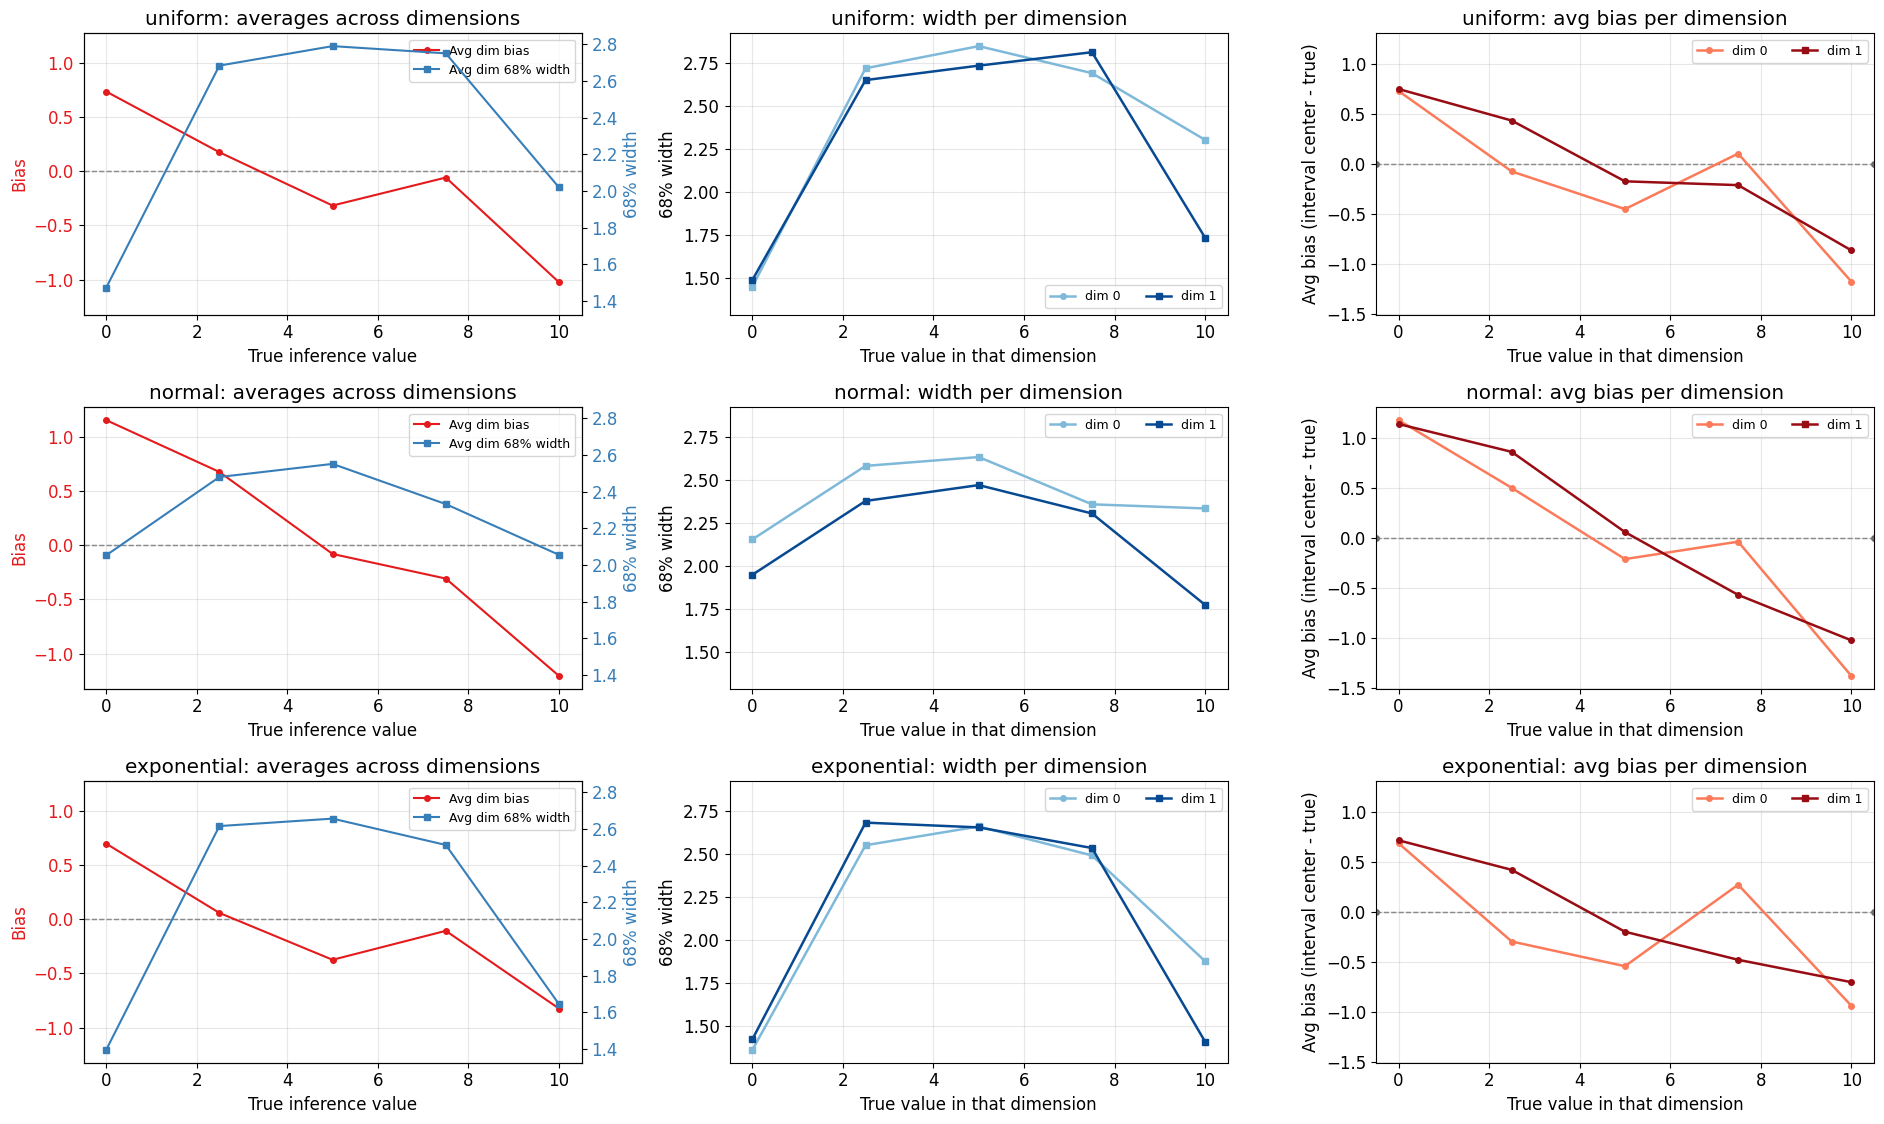

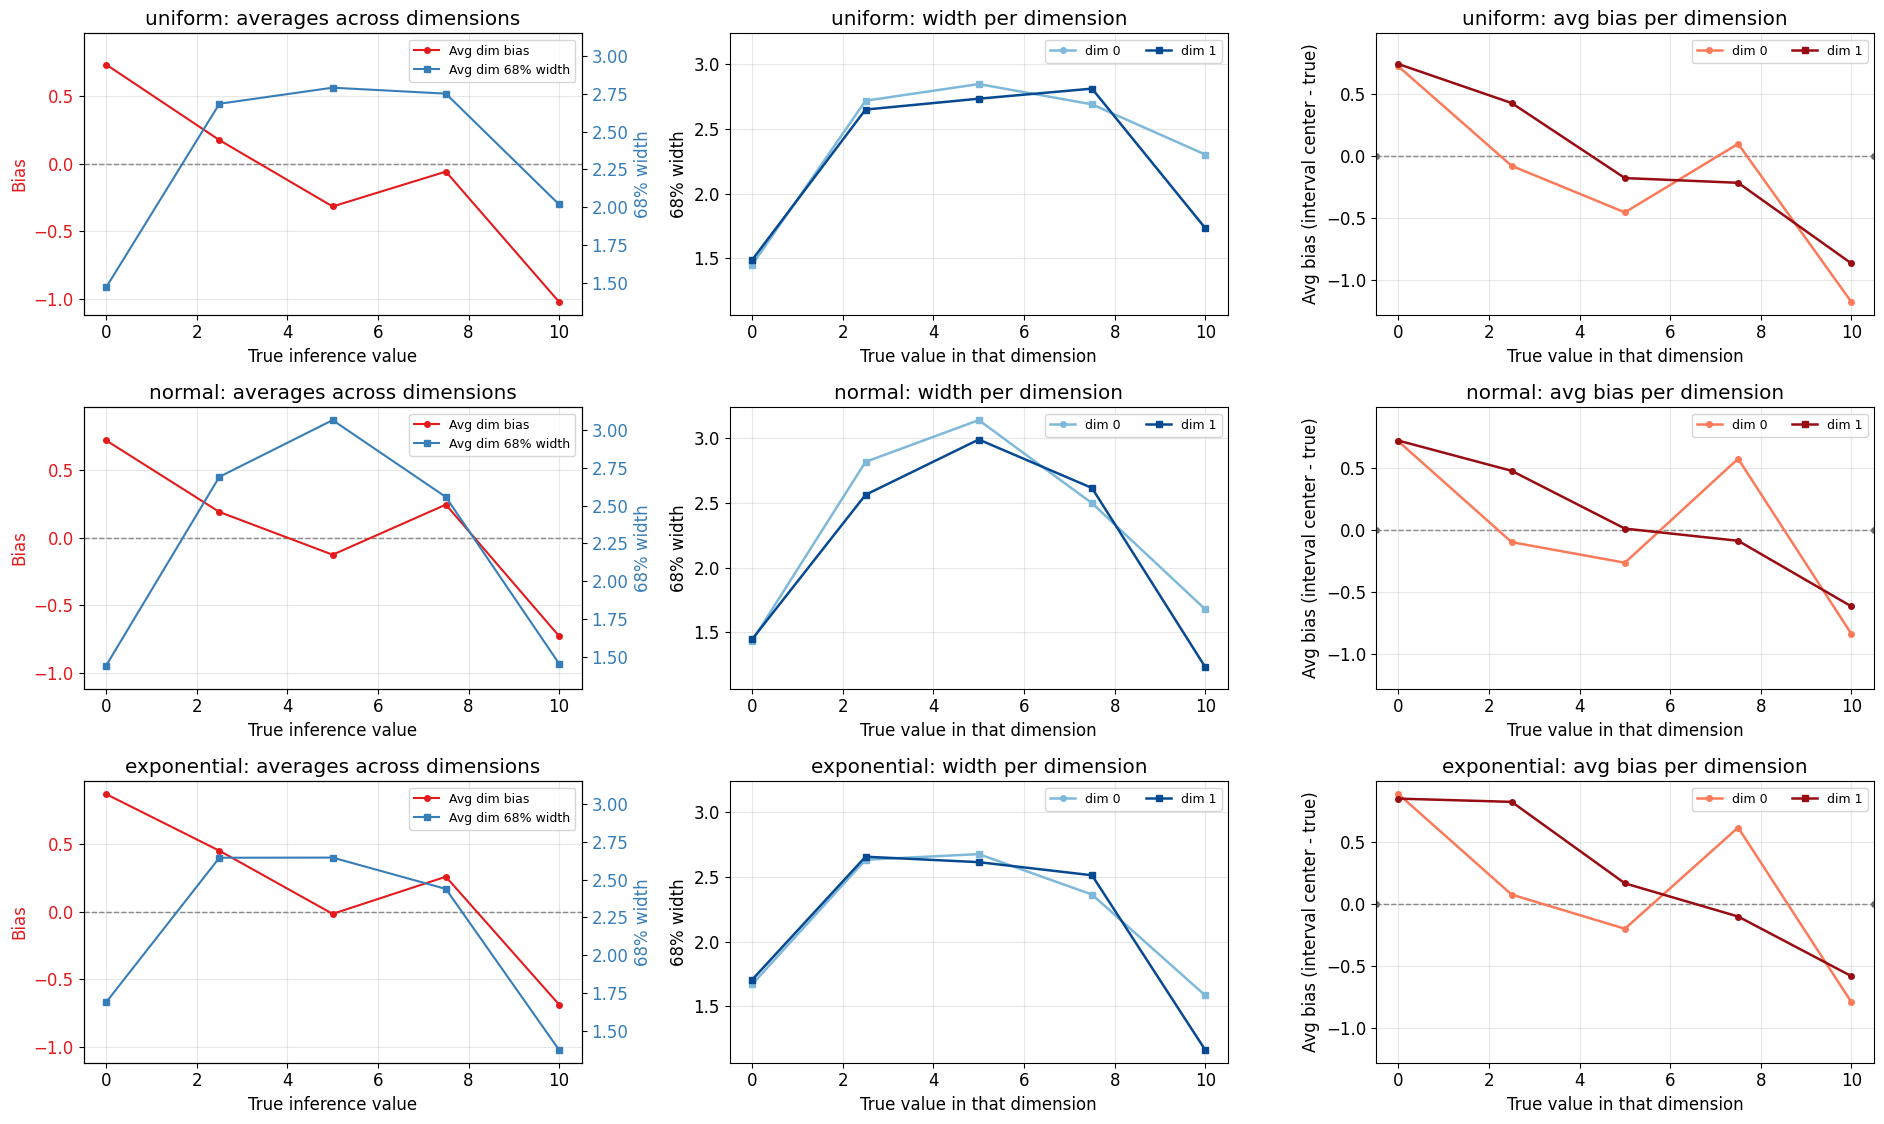

In [38]:
def plot_error_and_hpd_width(HPDs: dict, inference_data, all_posteriors, parameters_post, filename=None):
    _, parameter_combinations, _ = inference_data
    true_params = np.asarray(parameter_combinations, dtype=float)  # (N, n_dims)

    n_dims = len(parameters_post)
    n_posteriors = len(HPDs)

    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(
        nrows=n_posteriors,
        ncols=3,
        figsize=(19, 3.8 * n_posteriors),
        squeeze=False,
    )

    dim_lengths = [len(r) for r in parameters_post]

    markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
    blues = plt.cm.Blues(np.linspace(0.45, 0.9, max(n_dims, 2)))
    reds = plt.cm.Reds(np.linspace(0.45, 0.9, max(n_dims, 2)))

    def _parse_hpd_entry(entry, level="68"):
        raw = entry[level]

        intervals = None
        interval_combined = None

        if isinstance(raw, dict):
            intervals = raw.get("intervals", raw.get("interval", None))
            interval_combined = raw.get("interval_combined", raw.get("combined", None))
        elif isinstance(raw, (tuple, list)) and len(raw) == 2:
            intervals, interval_combined = raw[0], raw[1]
        else:
            intervals = raw

        intervals = np.asarray(intervals, dtype=float)

        if interval_combined is None:
            if intervals.ndim == 2 and intervals.shape[1] == 2:
                low = float(np.mean(intervals[:, 0]))
                high = float(np.mean(intervals[:, 1]))
                interval_combined = np.array([low, high], dtype=float)
            else:
                interval_combined = np.array([np.nan, np.nan], dtype=float)
        else:
            interval_combined = np.asarray(interval_combined, dtype=float)

        return intervals, interval_combined

    def _aggregate_curve_by_x(x, y, decimals=12):
        x_key = np.round(np.asarray(x, dtype=float), decimals=decimals)
        y = np.asarray(y, dtype=float)
        x_unique, inv = np.unique(x_key, return_inverse=True)
        y_avg = np.zeros(len(x_unique), dtype=float)
        for i in range(len(x_unique)):
            y_avg[i] = np.mean(y[inv == i])
        return x_unique, y_avg

    def _aggregate_per_dim_by_true_value(true_params_local, width_dims_local, bias_dims_local, decimals=12):
        width_curves = []
        bias_curves = []
        for d in range(n_dims):
            x_d = true_params_local[:, d]
            xw, yw = _aggregate_curve_by_x(x_d, width_dims_local[:, d], decimals=decimals)
            xb, yb = _aggregate_curve_by_x(x_d, bias_dims_local[:, d], decimals=decimals)
            width_curves.append((xw, yw))
            bias_curves.append((xb, yb))
        return width_curves, bias_curves

    def _aggregate_combined_from_dim_curves(curves_by_dim, decimals=12):
        x_all, y_all = [], []
        for x_d, y_d in curves_by_dim:
            x_all.extend(x_d.tolist())
            y_all.extend(y_d.tolist())
        if len(x_all) == 0:
            return np.array([], dtype=float), np.array([], dtype=float)
        return _aggregate_curve_by_x(np.asarray(x_all), np.asarray(y_all), decimals=decimals)

    panel_data = {}

    all_bias_comb, all_width_comb = [], []
    all_width_dims, all_bias_dims = [], []

    for prior_name, errors in HPDs.items():
        posts = all_posteriors[prior_name]
        N = len(posts)

        y_hat = np.zeros((N, n_dims), dtype=float)
        for idx, p in enumerate(posts):
            if isinstance(p, dict) and "map" in p:
                y_hat[idx, :] = np.asarray(p["map"], dtype=float)
                continue

            arr = np.asarray(p)
            if arr.ndim == 1:
                imax = int(np.argmax(arr))
                multi = np.unravel_index(imax, dim_lengths)
            else:
                multi = np.unravel_index(int(np.argmax(arr)), arr.shape)
            for d in range(n_dims):
                y_hat[idx, d] = parameters_post[d][multi[d]]

        width_dims = np.zeros((N, n_dims), dtype=float)
        bias_dims = np.zeros((N, n_dims), dtype=float)

        for i_e, e in enumerate(errors):
            intervals, _ = _parse_hpd_entry(e, level="68")

            for d in range(n_dims):
                low, high = float(intervals[d, 0]), float(intervals[d, 1])
                width_dims[i_e, d] = high - low
                bias_dims[i_e, d] = 0.5 * (low + high) - true_params[i_e, d]

        width_curves, bias_curves = _aggregate_per_dim_by_true_value(true_params, width_dims, bias_dims)

        x_comb, bias_comb = _aggregate_combined_from_dim_curves(bias_curves)
        _, width_comb = _aggregate_combined_from_dim_curves(width_curves)

        panel_data[prior_name] = {
            "x_comb": x_comb,
            "bias_comb": bias_comb,
            "width_comb": width_comb,
            "width_curves": width_curves,
            "bias_curves": bias_curves,
        }

        if len(bias_comb):
            all_bias_comb.extend(bias_comb.tolist())
        if len(width_comb):
            all_width_comb.extend(width_comb.tolist())
        for x_d, y_d in width_curves:
            if len(y_d):
                all_width_dims.extend(y_d.tolist())
        for x_d, y_d in bias_curves:
            if len(y_d):
                all_bias_dims.extend(y_d.tolist())

    def _lims(values, floor0=False):
        if len(values) == 0:
            return (0.0, 1.0)
        vmin, vmax = float(np.min(values)), float(np.max(values))
        pad = 0.05 * (vmax - vmin) if vmax > vmin else 0.1
        lo = vmin - pad
        hi = vmax + pad
        if floor0:
            lo = max(0.0, lo)
        return lo, hi

    bias_comb_ylim = _lims(all_bias_comb, floor0=False)
    width_comb_ylim = _lims(all_width_comb, floor0=True)
    width_dims_ylim = _lims(all_width_dims, floor0=True)
    bias_dims_ylim = _lims(all_bias_dims, floor0=False)

    for r, prior_name in enumerate(HPDs.keys()):
        pdata = panel_data[prior_name]
        x_comb = pdata["x_comb"]
        bias_comb = pdata["bias_comb"]
        width_comb = pdata["width_comb"]
        width_curves = pdata["width_curves"]
        bias_curves = pdata["bias_curves"]

        a1 = ax[r, 0]
        a1b = a1.twinx()
        l1 = a1.plot(x_comb, bias_comb, "o-", color="C0", markersize=4, label="Avg dim bias")
        l2 = a1b.plot(x_comb, width_comb, "s-", color="C1", markersize=4, label="Avg dim 68% width")

        a1.set_ylim(*bias_comb_ylim)
        a1b.set_ylim(*width_comb_ylim)
        a1.set_xlabel("True inference value")
        a1.set_ylabel("Bias", color="C0")
        a1b.set_ylabel("68% width", color="C1")
        a1.tick_params(axis="y", labelcolor="C0")
        a1b.tick_params(axis="y", labelcolor="C1")
        a1.grid(True, alpha=0.3)
        a1.set_title(f"{prior_name}: averages across dimensions")

        lines = l1 + l2
        a1.legend(lines, [ln.get_label() for ln in lines], loc="best", fontsize=9)

        a2 = ax[r, 1]
        for d in range(n_dims):
            x_d, y_d = width_curves[d]
            a2.plot(
                x_d,
                y_d,
                "-",
                linewidth=1.8,
                color=blues[d],
                marker=markers[d % len(markers)],
                markersize=4,
                label=f"dim {d}",
            )
        a2.set_ylim(*width_dims_ylim)
        a2.set_xlabel("True value in that dimension")
        a2.set_ylabel("68% width")
        a2.grid(True, alpha=0.3)
        a2.set_title(f"{prior_name}: width per dimension")
        a2.legend(loc="best", fontsize=9, ncol=min(n_dims, 3))

        a3 = ax[r, 2]
        for d in range(n_dims):
            x_d, y_d = bias_curves[d]
            a3.plot(
                x_d,
                y_d,
                "-",
                linewidth=1.8,
                color=reds[d],
                marker=markers[d % len(markers)],
                markersize=4,
                label=f"dim {d}",
            )
        a3.set_ylim(*bias_dims_ylim)
        a3.set_xlabel("True value in that dimension")
        a3.set_ylabel("Avg bias (interval center - true)")
        a3.grid(True, alpha=0.3)
        a3.set_title(f"{prior_name}: avg bias per dimension")
        a3.legend(loc="best", fontsize=9, ncol=min(n_dims, 3))

        for a in (a1, a1b, a2, a3):
            a.axhline(0.0, color="0.35", linestyle="--", linewidth=1.0, alpha=0.8, zorder=0)

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)

def _enforce_markers(fig, filename=None):
    for a in fig.axes:
        title = a.get_title().lower()
        if "width per dimension" in title:
            for ln in a.lines:
                ln.set_marker("s")
                ln.set_markersize(4)
        elif "avg bias per dimension" in title:
            for ln in a.lines:
                ln.set_marker("o")
                ln.set_markersize(4)

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)


plot_error_and_hpd_width(
    all_HPDs_posterior, inference_data, all_posteriors, all_parameters_in_range, filename=filename_error_and_hpd_width
)
_enforce_markers(plt.gcf(), filename=filename_error_and_hpd_width)
plot_error_and_hpd_width(
    all_HPDs_ratio, inference_data, all_ratios, all_parameters_in_range, filename=filename_error_and_hpd_width_ratios
)
_enforce_markers(plt.gcf(), filename=filename_error_and_hpd_width_ratios)

In [56]:
plot_errorbars(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, show_annotations=False, filename=filename_errorbars)
plot_errorbars(all_HPDs, inference_data, all_ratios, all_parameters_in_range, show_annotations=False, filename=filename_errorbars_ratios)
#plot_all_posteriors_contour(all_posteriors, inference_data, priors0, priors1, all_parameters_in_range, i_combination=210, zoom_factor=[1,.1], filename=filename_prior_per_parameter)
#plot_all_posteriors_contour(all_ratios, inference_data, priors0, priors1, all_parameters_in_range, i_combination=210, zoom_factor=[1,.1], filename=filename_prior_per_ratios)

NameError: name 'all_HPDs' is not defined

In [ ]:
inference_data = create_inference_data(n_parameters_to_infer=[4, 4], parameters_min_max=parameters_min_max, n_repititions_per_parameter=n_repititions_per_parameter)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(inference_data, all_parameters_in_range)
plot_errorbars(all_HPDs, inference_data, all_posteriors, all_parameters_in_range, filename=filename_errorbars)
plot_all_posteriors_contour(all_posteriors, inference_data, priors0, priors1, all_parameters_in_range, filename=filename_prior_per_parameter)
plot_all_posteriors_contour(all_ratios, inference_data, priors0, priors1, all_parameters_in_range, filename=filename_prior_per_ratios)


In [ ]:
filename_posteriors_data = get_filepath(f"posterior_errors/error_and_hpd_width.pkl", config)
if save:
    pickle.dump({
        "all_HPDs": all_HPDs,
        "inference_data": inference_data,
        "all_posteriors": all_posteriors,
        "all_ratios": all_ratios,
        "all_parameters_in_range": all_parameters_in_range,
        "n_repititions_per_parameter": n_repititions_per_parameter,
        "n_parameters": n_parameters
    }, open(filename_posteriors_data, "wb"))

#### Posterior Checks:

Check I: ratio expectation value

$1=\int p(x|\theta_0) dx = \int r(x|\theta_0) p(x) dx = \mathbb{E} [r(x|\theta_0)]$

i.e. if $\mathbb{E} [r(x|\theta_0)]=1$, then $r(x|\theta_0) = p(x|\theta_0) / p(x) = p(\theta_0 | x) / p(\theta_0)$ is plausible

In [ ]:
def calculate_individual_ratios(data, parameter):
    _, data_inputs = data
    parameters = parameter
    if isinstance(parameter, float) or isinstance(parameter, int):
        parameters = np.full(len(data_inputs), parameter)
    ratios = {}
    for model, prior in zip(models[0], priors):
        ratios_per_model = []
        for data_fixed, parameter_fixed in zip(data_inputs, parameters):
            input_post = torch.cat(
                tensors=[torch.tensor([x]).float().to(device).unsqueeze(1) for x in (data_fixed, parameter_fixed)],
                dim=1
            )
            model_out = model(input_post).cpu().detach().numpy().flatten()
            ratio = model_out / (1 - model_out)
            ratios_per_model += [ratio[0]]
        ratios[prior.__name__] = ratios_per_model
    return ratios

def calculate_all_ratios(data_inputs, test_parameters):
    all_ratios = {}
    for parameter in test_parameters:
        ratios = calculate_individual_ratios(data_inputs, parameter)
        for prior_name, ratio_values in ratios.items():
            if prior_name not in all_ratios:
                all_ratios[prior_name] = []
            all_ratios[prior_name] += [ratio_values]
    return all_ratios

In [ ]:
inference_data = create_inference_data(n_posterior=1000, margin=0, data_is_random=True, samples_per_n_posterior=1)
test_parameters = np.linspace(parameter_min, parameter_max, 5)
all_ratios = calculate_all_ratios(inference_data, test_parameters)

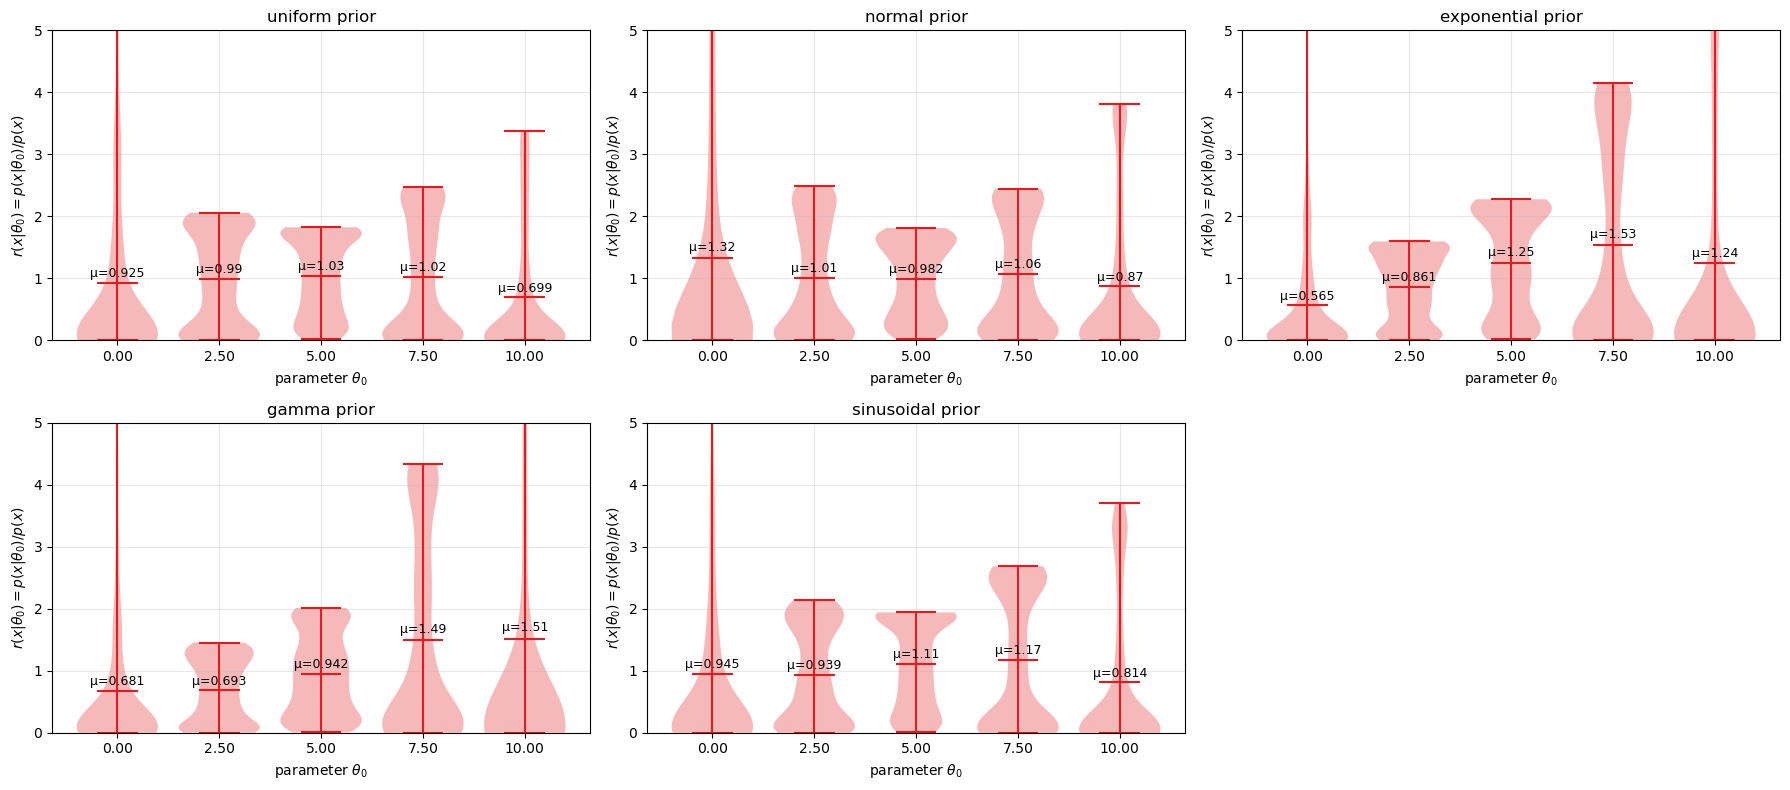

In [15]:
filename_ratio_violins = get_filepath(f"verifications/ratio_violins.svg", config) if save else None
plot_ratio_violins(all_ratios, test_parameters, filename=filename_ratio_violins)

Check II: reweighting

$R_{10}(x) = \frac{r(x|\theta_1)}{r(x|\theta_0)} = \frac{p(x|\theta_1)}{p(x|\theta_0)}$

if $p(x|\theta_1) = R_{10}(x)p(x|\theta_0)$: likelihood ratio trick holds

In [16]:
def compute_ratio(data, parameter, model):
    def _to_array_or_scalar(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        if np.isscalar(x):
            return x, 'scalar'
        x = np.asarray(x)
        assert x.ndim == 1, "Expected 1D input when passing an array-like."
        return x, 'vector'

    data_point, _t_data = _to_array_or_scalar(data)
    parameters, _t_param = _to_array_or_scalar(parameter)

    if _t_data == 'scalar' and _t_param == 'vector':
        data_point = np.full(parameters.shape, data_point, dtype=float)
    elif _t_data == 'vector' and _t_param == 'scalar':
        parameters = np.full(data_point.shape, parameters, dtype=float)
    elif _t_data == 'vector' and _t_param == 'vector':
        assert len(data_point) == len(parameters), "data and parameter must have the same length."
    elif _t_data == 'scalar' and _t_param == 'scalar':
        data_point = [data_point]
        parameters = [parameter]
    
    model_in = torch.cat(
        tensors=[torch.tensor(x).float().to(device).unsqueeze(1) for x in (data_point, parameters)],
        dim=1
    )
    model_out = model(model_in).cpu().detach().numpy().flatten()
    ratio = model_out / (1 - model_out)
    return ratio, model_out

def reweight_distributions(test_parameters, model_arr, n_test_data=int(1e6), n_bins=int(1e3)):
    all_ratios = {}
    all_outs = {}
    reweighting_distributions = {}
    reweighted_distributions = {}
    data_x = [generator.normal(loc=parameter, scale=config["data"]["std"], size=n_test_data) for parameter in test_parameters]
    for prior, model in zip(priors, model_arr):
        results = [compute_ratio(data_x[0], parameter, model) for parameter in test_parameters]
        ratios = [result[0] for result in results]
        model_outs = [result[1] for result in results]
        all_ratios[prior.__name__] = ratios
        all_outs[prior.__name__] = model_outs
        reweighting_distributions[prior.__name__] = ratios[1] / ratios[0]
        reweighted_distribution, edges = np.histogram(
            data_x[0],
            bins=n_bins,
            weights=reweighting_distributions[prior.__name__],
            density=False,
            #range=config["data"]["parameter_range"]
        )
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        reweighted_distributions[prior.__name__] = (bin_centers, reweighted_distribution)
    return data_x, reweighted_distributions, reweighting_distributions, all_outs

In [18]:
n_test_data = int(1e7)
n_bins = int(1e3)
test_parameters = [(3, 7)] #, (7, 8), (4, 7), (6, 4)]
for i, model_arr in enumerate(models):
    for test_parameter_set in test_parameters:
        data_x, reweighted_distributions, reweighting_distributions, all_outs = reweight_distributions(test_parameter_set, model_arr, n_test_data, n_bins)
        filename_overlap_integrals = get_filepath(f"verifications/reweighting_{i}/overlap_integrals_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        filename_reweighted_distributions = get_filepath(f"verifications/reweighting_{i}/reweighted_distributions_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        #plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=filename_overlap_integrals)
        plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameter_set, n_bins, filename=filename_reweighted_distributions)
        #plot_all_outs_histograms(all_outs, test_parameter_set, n_bins=50, filename=None)

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.38 GiB. GPU 0 has a total capacity of 10.57 GiB of which 521.00 MiB is free. Process 794040 has 3.87 GiB memory in use. Process 1286439 has 660.00 MiB memory in use. Including non-PyTorch memory, this process has 5.14 GiB memory in use. Of the allocated memory 4.93 GiB is allocated by PyTorch, and 8.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [64]:
import time

# Small smoke benchmark for get_posteriors_and_errors
bench_n_grid = 60
bench_reps = 1
bench_n_per_dim = 2

bench_parameters_min_max = config["data"]["parameter_range"]
bench_all_parameters_in_range = [
    np.linspace(bench_parameters_min_max[0], bench_parameters_min_max[1], bench_n_grid)
    for _ in range(config["data"]["n_parameters"])
]
bench_inference_data = create_inference_data(
    bench_parameters_min_max,
    n_parameters_to_infer_per_dim=bench_n_per_dim,
    margin=0.1,
    n_repititions_per_parameter=bench_reps,
    data_is_random=False,
    parameters_to_infer=None,
)

original_cpu_count = mp.cpu_count
try:
    # Force serial path through existing function
    mp.cpu_count = lambda: 1
    t0 = time.perf_counter()
    _ = get_posteriors_and_errors(bench_inference_data, bench_all_parameters_in_range)
    t_serial = time.perf_counter() - t0

    # Restore multiprocessing path
    mp.cpu_count = original_cpu_count
    t0 = time.perf_counter()
    _ = get_posteriors_and_errors(bench_inference_data, bench_all_parameters_in_range)
    t_parallel = time.perf_counter() - t0
finally:
    mp.cpu_count = original_cpu_count

speedup = t_serial / t_parallel if t_parallel > 0 else np.nan
print(f"Benchmark setup: grid={bench_n_grid}^{{{config['data']['n_parameters']}}}, combos_per_dim={bench_n_per_dim}, reps={bench_reps}")
print(f"Serial:   {t_serial:.3f} s")
print(f"Parallel: {t_parallel:.3f} s")
print(f"Speedup:  {speedup:.2f}x")

Calculating posteriors and errors...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 13.19it/s]

Benchmark setup: grid=60^{2}, combos_per_dim=2, reps=1
Serial:   0.076 s
Parallel: 0.913 s
Speedup:  0.08x


In [67]:
import time

# Larger benchmark sweep to find a positive multiprocessing speedup
benchmark_candidates = [
    {"bench_n_grid": 120, "bench_n_per_dim": 4, "bench_reps": 2},
    {"bench_n_grid": 150, "bench_n_per_dim": 5, "bench_reps": 2},
    {"bench_n_grid": 180, "bench_n_per_dim": 5, "bench_reps": 3},
    {"bench_n_grid": 200, "bench_n_per_dim": 6, "bench_reps": 3},
    {"bench_n_grid": 220, "bench_n_per_dim": 6, "bench_reps": 4},
]

results = []
original_cpu_count = mp.cpu_count
positive = None

for cfg in benchmark_candidates:
    bench_n_grid = cfg["bench_n_grid"]
    bench_n_per_dim = cfg["bench_n_per_dim"]
    bench_reps = cfg["bench_reps"]

    bench_parameters_min_max = config["data"]["parameter_range"]
    bench_all_parameters_in_range = [
        np.linspace(bench_parameters_min_max[0], bench_parameters_min_max[1], bench_n_grid)
        for _ in range(config["data"]["n_parameters"])
]
    bench_inference_data = create_inference_data(
        bench_parameters_min_max,
        n_parameters_to_infer_per_dim=bench_n_per_dim,
        margin=0.1,
        n_repititions_per_parameter=bench_reps,
        data_is_random=False,
        parameters_to_infer=None,
    )

    try:
        mp.cpu_count = lambda: 1
        t0 = time.perf_counter()
        _ = get_posteriors_and_errors(bench_inference_data, bench_all_parameters_in_range)
        t_serial = time.perf_counter() - t0

        mp.cpu_count = original_cpu_count
        t0 = time.perf_counter()
        _ = get_posteriors_and_errors(bench_inference_data, bench_all_parameters_in_range)
        t_parallel = time.perf_counter() - t0
    finally:
        mp.cpu_count = original_cpu_count

    speedup = t_serial / t_parallel if t_parallel > 0 else np.nan
    row = {
        "bench_n_grid": bench_n_grid,
        "bench_n_per_dim": bench_n_per_dim,
        "bench_reps": bench_reps,
        "serial_s": t_serial,
        "parallel_s": t_parallel,
        "speedup": speedup,
    }
    results.append(row)

    print(
        f"grid={bench_n_grid}^{config['data']['n_parameters']}, "
        f"combos_per_dim={bench_n_per_dim}, reps={bench_reps} -> "
        f"serial={t_serial:.3f}s, parallel={t_parallel:.3f}s, speedup={speedup:.2f}x"
    )

    if speedup > 1.0:
        positive = row
        break

if positive is None:
    print("No positive speedup found in tested configurations.")
else:
    print("\nFirst positive speedup configuration:")
    print(
        f"grid={positive['bench_n_grid']}^{config['data']['n_parameters']}, "
        f"combos_per_dim={positive['bench_n_per_dim']}, reps={positive['bench_reps']}, "
        f"serial={positive['serial_s']:.3f}s, parallel={positive['parallel_s']:.3f}s, "
        f"speedup={positive['speedup']:.2f}x"
    )

Calculating posteriors and errors...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 96/96 [00:02<00:00, 33.98it/s]


grid=120^2, combos_per_dim=4, reps=2 -> serial=0.878s, parallel=2.833s, speedup=0.31x


Calculating posteriors and errors...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:04<00:00, 33.31it/s]


grid=150^2, combos_per_dim=5, reps=2 -> serial=1.992s, parallel=4.514s, speedup=0.44x


Calculating posteriors and errors...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:04<00:00, 47.03it/s]


grid=180^2, combos_per_dim=5, reps=3 -> serial=3.513s, parallel=4.798s, speedup=0.73x


Calculating posteriors and errors...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 324/324 [00:07<00:00, 44.40it/s]


grid=200^2, combos_per_dim=6, reps=3 -> serial=6.377s, parallel=7.314s, speedup=0.87x


Calculating posteriors and errors...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 432/432 [00:07<00:00, 54.64it/s]

grid=220^2, combos_per_dim=6, reps=4 -> serial=9.860s, parallel=7.928s, speedup=1.24x

First positive speedup configuration:
grid=220^2, combos_per_dim=6, reps=4, serial=9.860s, parallel=7.928s, speedup=1.24x


In [17]:
import time
print("device:", device, "cuda:", torch.cuda.is_available())

bench_n_grid = 180
bench_reps = 3
bench_n_per_dim = 5
bench_parameters_min_max = config["data"]["parameter_range"]
bench_all_parameters_in_range = [
    np.linspace(bench_parameters_min_max[0], bench_parameters_min_max[1], bench_n_grid)
    for _ in range(config["data"]["n_parameters"])
]
bench_inference_data = create_inference_data(
    bench_parameters_min_max,
    n_parameters_to_infer_per_dim=bench_n_per_dim,
    margin=0.1,
    n_repititions_per_parameter=bench_reps,
    data_is_random=False,
    parameters_to_infer=None,
 )

t0 = time.perf_counter()
_ = get_posteriors_and_errors(bench_inference_data, bench_all_parameters_in_range)
t_mp = time.perf_counter() - t0

t0 = time.perf_counter()
_ = get_posteriors_errors(bench_inference_data, bench_all_parameters_in_range)
t_gpu = time.perf_counter() - t0

print(f"mp version:   {t_mp:.3f} s")
print(f"gpu batched:  {t_gpu:.3f} s")
print(f"speedup:      {t_mp / t_gpu:.2f}x")

device: cuda cuda: True


Calculating posteriors and errors...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:06<00:00, 35.31it/s]
Calculating posteriors and errors (GPU batched)...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:03<00:00, 74.26it/s]

mp version:   6.375 s
gpu batched:  3.050 s
speedup:      2.09x
